# 最初に回すコード

##モジュール＋マウント


In [1]:
from google.colab import drive
drive.mount('./drive')
drive_root_dir="./drive/My Drive/aaaaaa"
import os
!ls
os.chdir(drive_root_dir)

Mounted at ./drive
drive  sample_data


In [2]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import itertools
import os
import cv2
import random
import time
from PIL import Image
from tqdm import tqdm
import tensorflow as tf
import image_rotate as tfa
from datetime import datetime
import re
import scipy.ndimage as ndimage
from skimage import data, img_as_float
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.metrics import peak_signal_noise_ratio
from skimage.util import random_noise
from skimage.restoration import unwrap_phase
from skimage import io, color, filters
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, Input, Activation, BatchNormalization, Dense, MaxPooling2D, Conv2DTranspose

## 自作関数

In [3]:
output_gif = "animated.gif"

In [4]:
def timer(func):
  def wrapper(*args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    end = time.perf_counter()
    print(f'{func.__name__} took {end - start:.5f} seconds')
    return result
  return wrapper

In [5]:
def save_gif(dir, flame=1000,loop=0):
    image_folder = dir + "/images"
    output_dir = os.path.join(dir, "animation.gif")
    # 拡張子が .png または .tif の画像を読み込む（昇順でソート）
    image_files = sorted([f for f in os.listdir(image_folder) if f.endswith(('.png', '.tif', '.jpg'))],
                         key=extract_number)

    # フルパスに変換して画像を読み込み
    images = [Image.open(os.path.join(image_folder, f)) for f in image_files]

    # GIFとして保存（ループあり、各フレーム200ms）
    images[0].save(output_dir,
                save_all=True,
                append_images=images[1:],
                duration=flame,   # 各フレーム表示時間（ms）
                loop=loop)

# 数値をキーにして自然順でソート
def extract_number(filename):
    match = re.search(r'\d+', filename)
    return int(match.group()) if match else -1

# 2次元配列を画像で保存する関数
def save_tif(data,title,path):
    data=Image.fromarray(data)
    data.save("./"+ path + "/" + title + ".tif")

# 最終的な推定画像に使う合成開口のローパスフィルター
def lowpass(img):
    return abs(np.fft.ifft2(np.fft.ifftshift( AS_mask * np.fft.fftshift(np.fft.fft2(img)) )))

# ガウシアンノイズを与える関数
def addGaussianNoise(src):
    row,col= src.shape
    mean = 0
    sigma = np.sqrt(src)
    gauss = np.random.normal(mean,sigma,(row,col))
    gauss = gauss.reshape(row,col)
    noisy = src + gauss
    return noisy

# 2Dフーリエ変換
def FT(f):
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(f)))

# 2D逆フーリエ変換
def iFT(f):
    return np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(f)))

# 平面波展開（TensorFlow用）
def ASM_tf(input_field, pixel_size, dz, xlambda):
    input_shape = input_field.shape
    # 周波数座標
    dfx = 1.0 / (pixel_size * input_shape[1])
    dfy = 1.0 / (pixel_size * input_shape[0])
    fx = np.arange(-input_shape[1] / 2, input_shape[1] / 2) * dfx
    fy = np.arange(-input_shape[0] / 2, input_shape[0] / 2) * dfy
    fx = tf.constant(fx, dtype=tf.float32)
    fy = tf.constant(fy, dtype=tf.float32)
    fx_mesh, fy_mesh = tf.meshgrid(fx, fy)
    fz2 = 1.0 / xlambda ** 2 - fx_mesh ** 2 - fy_mesh ** 2
    fz2 = tf.where(fz2 > 0.0, fz2, 0.0)
    fz = tf.sqrt(fz2)
    # 伝達関数Hの計算
    H_phase = 2 * np.pi * fz * dz
    H = tf.complex(tf.cos(H_phase), tf.sin(H_phase))

    # 伝搬計算本体
    fft_input = tf.signal.fftshift(tf.signal.fft2d(input_field))
    fft_output = fft_input * H
    output = tf.signal.ifft2d(tf.signal.ifftshift(fft_output))
    return output

# Legendre多項式の基底関数を作成する関数．引数：(最大次数，X_mesh, Y_mesh)
def legendre2D( deg, X, Y ):
    m,n     = X.shape
    npol    = int(0.5*(deg+1)*(deg+2))
    B       = np.zeros((npol,m,n))
    for i in np.arange(deg+1):
        for k in np.arange(i+1):
            cx                  = np.random.rand(i+1) * 2 -1
            cy                  = np.random.rand(i+1) * 2 -1
            cx[i-k]             = 1
            cy[k]               = 1
            B[int(i*(i+1)/2)+k] = np.polynomial.legendre.legval(X,cx)*np.polynomial.legendre.legval(Y,cy)
    B[0] = 0*B[0]
    B[1] = 0*B[1]
    B[2] = 0*B[2]
    return B

# Legendre多項式の基底関数を作成する関数．引数：(最大次数，X_mesh, Y_mesh)
def legendreBasis2D( deg, X, Y ):
    m,n     = X.shape
    npol    = int(0.5*(deg+1)*(deg+2))
    B       = np.zeros((npol,m,n))
    for i in np.arange(deg+1):
        for k in np.arange(i+1):
            cx                  = np.zeros(i+1)
            cy                  = np.zeros(i+1)
            cx[i-k]             = 1
            cy[k]               = 1
            B[int(i*(i+1)/2)+k] = np.polynomial.legendre.legval(X,cx)*np.polynomial.legendre.legval(Y,cy)
    B[0] = 0*B[0]
    B[1] = 0*B[1]
    B[2] = 0*B[2]
    return B

# 基底関数と係数から波面を作る関数
def polyEval2D( coef, basis ):
    coef = np.array(coef)
    coef = np.expand_dims(np.expand_dims(coef, -1), -1)
    pupil = np.sum(coef*basis, axis=0)
    # coef = tf.reshape(coef, [-1, 1, 1])
    # pupil = tf.reduce_sum(basis*coef, axis=0)
    return pupil

# 位置ずれ補正用Legendre多項式（１次関数のみ）
def Legendre_shift(z,x,y):
    out = 5*z[0]*(1.7321*x) + \
          5*z[1]*(1.7321*y)
    return out

# SSIMでLossを計算する関数．（普通にMSEなどでlossをとるよりSSIMでとる方が推定がうまくいく場合が多い．）
def ssim_loss(y_true, y_pred):
    ssim = tf.image.ssim(y_true, y_pred, max_val=1, filter_size=11, filter_sigma=3, k1=0.01, k2=0.03 )
    return ssim


def score_img(coef, theta_x, theta_y, defocus = -40e-6, rot_angle = 8,crop_size=356):

  pupil = make_wavefront_oblique(coef, theta_x, theta_y)
  # print(coef)


  img_total = np.zeros((crop_size, crop_size))
  angle = 2*np.pi/(360/rot_angle)
  angle_num = int(360/rot_angle)
  img_list = []
  angle_list=[]
  for i in range(angle_num):
    # if i*rot_angle >=180:
    #   break
    angle_list.append(i*rot_angle)
    rot_A = np.array(tfa.rotate(obA, tf.constant(-1.0 * i * angle)))
    rot_P = np.array(tfa.rotate(obP, tf.constant(-1.0 * i * angle)))
    # コヒーレント結像
    object_img = rot_A * np.exp(rot_P * 1j)
    object_imgFT = np.fft.fftshift(np.fft.fft2(object_img))
    imSeqLowFT = object_imgFT * pupil
    exp_field = np.fft.ifft2(np.fft.ifftshift(imSeqLowFT))


    # 面ブレを考慮したデフォーカスを与える．
    dz = defocus
    exp_field = ASM_tf(exp_field, pixel_size, dz, xlambda)



    exp_intensity = np.abs(exp_field)**2
    scale = np.max(exp_intensity)
    exp_intensity = photon * exp_intensity/scale
    exp_intensity = np.abs(addGaussianNoise(exp_intensity))
    exp_intensity = exp_intensity/photon*scale
    #ノイズ除去
    exp_intensity = np.expand_dims(exp_intensity, axis=-1)
    sigma_est = np.mean(estimate_sigma(exp_intensity, channel_axis=-1))
    patch_kw = dict(
        patch_size=5,  # 5x5 patches
        patch_distance=6,  # 13x13 search area
        channel_axis=-1,
    )
    # fast algorithm, sigma provided
    exp_intensity = denoise_nl_means(
        exp_intensity, h=0.6 * sigma_est, sigma=sigma_est, fast_mode=True, **patch_kw
    )
    exp_intensity = np.array(tfa.rotate(exp_intensity, tf.constant(i * angle)))

    #各画像の描写
    # plt.imshow(exp_intensity, cmap="gray",vmax=2.0, vmin=0.0)
    # plt.colorbar()
    # plt.axis('off')
    # plt.show()


    img_out = exp_intensity[imax//2-int(crop_size//2) : imax//2+int(crop_size//2),
                            jmax//2-int(crop_size//2) : jmax//2+int(crop_size//2)]
    img_out /= np.max(img_out)
    # plt.imshow(img_out, cmap="gray",vmax=1.0, vmin=0.0)
    # plt.colorbar()
    # plt.axis('off')
    # plt.show()
    img_list.append(img_out)
    img_total += img_out
  img_total /= len(img_list)

  # print(rms_calculate(pupil))
  # plt.imshow(img_total, cmap="gray",vmin=0, vmax=2.0)
  # plt.colorbar()
  # plt.axis('off')
  # plt.show()

  # plt.imshow(psf(pupil)[imax//2-int(crop_size//4) : imax//2+int(crop_size//4),
  #                       jmax//2-int(crop_size//4) : jmax//2+int(crop_size//4)], cmap = "jet")
  # plt.axis('off')
  # plt.show()
  return img_total

def generate_coef_with_norm(norm, mode):
    numbers = np.random.rand(mode) * 2 * norm - norm
    current_norm = np.linalg.norm(numbers)
    numbers = numbers * (norm / current_norm)
    return numbers.tolist()

def pseudo_incoherent(coef, theta_x,theta_y,  defocus = 0.0e-6, rot_angle=20, crop_size=256):
    pupil = make_wavefront_oblique(coef, theta_x, theta_y)
    pupil_cp = cp.array(pupil)
    # print(coef)
    img_total = np.zeros((crop_size, crop_size))
    angle = 2*np.pi/(360/rot_angle)
    angle_num = int(360/rot_angle)
    img_list = []
    for i in range(angle_num):
        rot_A = np.array(tfa.rotate(obA, tf.constant(-1.0 * i * angle)))
        rot_P = np.array(tfa.rotate(obP, tf.constant(-1.0 * i * angle)))
        # コヒーレント結像
        object_img = rot_A * np.exp(rot_P * 1j)
        object_img = cp.array(object_img)
        object_imgFT = cp.fft.fftshift(cp.fft.fft2(object_img))
        imSeqLowFT = object_imgFT * pupil_cp
        exp_field = cp.fft.ifft2(cp.fft.ifftshift(imSeqLowFT))
        exp_field = cp.asnumpy(exp_field)

        #デフォーカス付与
        exp_field = ASM_tf(exp_field, pixel_size, defocus, xlambda)
        exp_intensity = np.abs(exp_field)**2

        #ノイズ付与
        scale = np.max(exp_intensity)
        exp_intensity = photon * exp_intensity/scale
        exp_intensity = np.abs(addGaussianNoise(exp_intensity))
        exp_intensity = exp_intensity/photon*scale

        #ノイズ除去
        exp_intensity = np.expand_dims(exp_intensity, axis=-1)
        sigma_est = np.mean(estimate_sigma(exp_intensity, channel_axis=-1))
        patch_kw = dict(
            patch_size=5,  # 5x5 patches
            patch_distance=6,  # 13x13 search area
            channel_axis=-1,
        )
        # fast algorithm, sigma provided
        exp_intensity = denoise_nl_means(
            exp_intensity, h=0.6 * sigma_est, sigma=sigma_est, fast_mode=True, **patch_kw
        )

        #向きをそろえる
        exp_intensity = np.array(tfa.rotate(exp_intensity, tf.constant(i * angle)))
        img_out = exp_intensity[imax//2-int(crop_size//2) : imax//2+int(crop_size//2),
                                jmax//2-int(crop_size//2) : jmax//2+int(crop_size//2)]
        img_out /= np.max(img_out)
        img_list.append(img_out)
        img_total += img_out
    img_total /= len(img_list)
    return img_list, img_total

def phase_imaging(coef, theta_x=0,theta_y=0,defocus=0):
  pupil = make_wavefront_oblique(coef, theta_x, theta_y)
  # print(coef)

  # コヒーレント結像
  object_img = obA * np.exp(obP * 1j)
  object_imgFT = np.fft.fftshift(np.fft.fft2(object_img))
  imSeqLowFT = object_imgFT * pupil
  exp_field = np.fft.ifft2(np.fft.ifftshift(imSeqLowFT))


  # 面ブレを考慮したデフォーカスを与える．
  dz = defocus
  exp_field = ASM_tf(exp_field, pixel_size, dz, xlambda)
  exp_phase = np.angle(exp_field)
  exp_phase_unwrap = np.unwrap(exp_phase, axis=0)
  exp_phase_unwrap = np.unwrap(exp_phase_unwrap, axis=1)



  return exp_phase_unwrap

def imaging(coef, theta_x=0,theta_y=0,defocus=0):
  pupil = make_wavefront_oblique(coef, theta_x, theta_y)
  # print(coef)

  # コヒーレント結像
  object_img = obA * np.exp(obP * 1j)
  object_imgFT = np.fft.fftshift(np.fft.fft2(object_img))
  imSeqLowFT = object_imgFT * pupil
  exp_field = np.fft.ifft2(np.fft.ifftshift(imSeqLowFT))


  # 面ブレを考慮したデフォーカスを与える．
  dz = defocus
  exp_field = ASM_tf(exp_field, pixel_size, dz, xlambda)
  exp_phase = np.angle(exp_field)
  exp_phase_unwrap = np.unwrap(exp_phase, axis=0)
  exp_phase_unwrap = np.unwrap(exp_phase_unwrap, axis=1)

  exp_intensity = np.abs(exp_field)**2


  return exp_intensity, exp_phase_unwrap

def psf(pupil):
  exp_field = np.fft.fftshift(np.fft.fft2(np.fft.fftshift(pupil)))
  exp_intensity = np.abs(exp_field)**2
  return exp_intensity


In [6]:
def Legendre_basis_6(x, y):
    basis_list = []
    basis_list.append(0*np.ones(x.shape))  # dummy mode 0
    basis_list.append(1.7321*x)
    basis_list.append(1.7321*y)
    basis_list.append(3.3541*x**2-1.1180)
    basis_list.append(3.0*x*y)
    basis_list.append(3.3541*y**2-1.1180)
    basis_list.append(6.6144*x**3-3.9686*x)
    basis_list.append(5.8095*x**2*y-1.9365*y)
    basis_list.append(5.8095*x*y**2-1.9365*x)
    basis_list.append(6.6144*y**3-3.9686*y)
    basis_list.append(13.125*x**4-11.25*x**2+1.125)
    basis_list.append(11.4564*x**3*y-6.8739*x*y)
    basis_list.append(11.25*x**2*y**2 - 3.75*x**2 - 3.75*y**2 + 1.25)
    basis_list.append(11.4564*x*y**3 - 6.8739*x*y)
    basis_list.append(13.125*y**4 - 11.25*y**2 + 1.125)
    basis_list.append(26.1184*x**5 - 29.0205*x**3 + 6.2187*x)
    basis_list.append(22.7332*x**4*y - 19.4856*x**2*y + 1.9486*y)
    basis_list.append(22.1853*x**3*y**2 - 7.3951*x**3 - 13.3112*x*y**2 + 4.4371*x)
    basis_list.append(22.1853*x**2*y**3 - 7.3951*y**3 - 13.3112*x**2*y + 4.4371*y)
    basis_list.append(22.7332*x*y**4 - 19.4856*x*y**2 + 1.9486*x)
    basis_list.append(26.1184*y**5 - 29.0205*y**3 + 6.2187*y)

    basis_list.append(52.0551*x**6 - 70.9843*x**4 + 23.6614*x**2 - 1.1267)  # L_60
    basis_list.append(45.2384*x**5*y - 50.2649*x**3*y + 10.7711*x*y)        # あやふや
    basis_list.append(44.0524*x**4*y**2 - 51.5292*x**2*y**2 + 18.1300*y**2 - 1.0737)  # あやふや
    basis_list.append(37.9628*x**3*y**3 - 30.3709*x*y**3 - 30.3709*x**3*y + 6.0382*x*y)  #あやふや
    basis_list.append(44.0524*x**2*y**4 - 51.5292*x**2*y**2 + 18.1300*x**2 - 1.0737)  # あやふや
    basis_list.append(45.2384*x*y**5 - 50.2649*x*y**3 + 10.7711*x*y)        # あやふや
    basis_list.append(52.0551*y**6 - 70.9843*y**4 + 23.6614*y**2 - 1.1267)  # L_06
    return np.array(basis_list)


In [7]:
def make_wavefront(coef):# 瞳関数の作成
    pupil = np.array(polyEval2D(coef, B)) * CTF
    # pupil = np.clip(pupil, -np.pi, np.pi)
    pupil = (np.cos(pupil) + 1.0j*np.sin(pupil)) * CTF
    return pupil

def make_wavefront_oblique(coef, theta_x, theta_y, pixel_size=16*1e-9, m=512, NA=1.5e-3, xlambda=(12.4/9.884)*1e-10):# 瞳関数の作成
    aperture = pixel_size * m * 2.0 * np.tan(NA)/xlambda     # [pixel]

    shift_x = pixel_size * m * 2.0 * np.tan(theta_x)/xlambda     # [pixel]
    shift_x = int(shift_x)

    shift_y = pixel_size * m * 2.0 * np.tan(theta_y)/xlambda     # [pixel]
    shift_y = int(shift_y)

    # 開口マスク作成
    CTF = np.zeros((n,m))
    CTF[n//2-int(aperture//2) : n//2 + int(aperture//2),
        m//2-int(aperture//2) : m//2+int(aperture//2)] = 1.0
    # plt.subplot(1,2,1)
    # plt.title("CTF")
    # plt.imshow(CTF)
    # plt.show()
    # plt.imshow(np.array(polyEval2D(coef, B)))
    # plt.colorbar()
    # plt.show()

    pupil = np.array(polyEval2D(coef, B)) * CTF
    # pupil = np.clip(pupil, -np.pi, np.pi)
    pupil = (np.cos(pupil) + 1.0j*np.sin(pupil)) * CTF
    pupil = np.roll(pupil, (shift_x, shift_y), axis = (0, 1))
    return pupil


def ssim_culc(pupil, angle = 2*np.pi/4):
    rot_A = np.array(tfa.rotate(obA, tf.constant(-1.0*0)))
    rot_P = np.array(tfa.rotate(obP, tf.constant(-1.0*0)))
    # コヒーレント結像
    object_img = rot_A * np.exp(rot_P * 1j)
    object_imgFT = np.fft.fftshift(np.fft.fft2(object_img))
    imSeqLowFT = object_imgFT * pupil
    exp_field = np.fft.ifft2(np.fft.ifftshift(imSeqLowFT))
    exp_intensity = np.abs(exp_field)**2
    img_out = np.sqrt(exp_intensity)
    img_out = img_out #[imax//2-int(363//2) : imax//2+int(363//2),jmax//2-int(363//2) : jmax//2+int(363//2)]
    # plt.imshow(img_out,cmap='gray')
    # plt.colorbar()
    # plt.show()

    rot_A = np.array(tfa.rotate(obA, tf.constant(-1.0*angle)))
    rot_P = np.array(tfa.rotate(obP, tf.constant(-1.0*angle)))
    # コヒーレント結像
    object_rot = rot_A * np.exp(rot_P * 1j)
    object_rotFT = np.fft.fftshift(np.fft.fft2(object_rot))
    imSeqLow_rotFT = object_rotFT * pupil
    exp_field_rot = np.fft.ifft2(np.fft.ifftshift(imSeqLow_rotFT))
    exp_intensity_rot = np.abs(exp_field_rot)**2
    img_rot = np.sqrt(exp_intensity_rot)
    img_rot = img_rot #[imax//2-int(363//2) : imax//2+int(363//2),jmax//2-int(363//2) : jmax//2+int(363//2)]
    img_rot = np.array(tfa.rotate(img_rot, tf.constant(angle)))
    # plt.imshow(img_rot,cmap='gray')
    # plt.colorbar()
    # plt.show()
    img_cul0 = tf.expand_dims(img_out, axis=-1)
    img_cul1 = tf.expand_dims(img_rot, axis=-1)
    score = ssim_loss(img_cul0, img_cul1).numpy()
    return score.item()

def rms_calculate(pupil):
  return np.sqrt(np.mean(np.angle(pupil[n//2-int(aperture//2) : n//2+int(aperture//2),m//2-int(aperture//2) : m//2+int(aperture//2)])**2))

## シミュレーション条件の設定

In [8]:
m = 512                 # 画像サイズ（横）
n = 512                 # 画像サイズ（縦）
rot_angle = 2*np.pi/90   # 1step回転角度
noise_flag = True       # ノイズを付与するかどうかのflag

xlambda = (12.4/9.884)*1e-10               # 波長. [m]
pixel_size = 16*1e-9                       # ピクセルサイズ. [m]
NA = 1.5e-3
thickness = 500.0e-9                       # スターチャート厚み. [m]
refraction = -1.96838E-05+4.074499E-06j    # 屈折率．Ta:9.884keV
coef_w = 4.0     # Legendre多項式の係数幅

photon = 500      # 光子数
max_shift = 6     # 位置ズレ最大. [pixel]
max_defocus = 50  # 最大面ブレ量. [um]

maxD    = 5                    # Legendre多項式の最大次数
mode = (maxD+1)*(maxD+2)//2     # Legendre modeの数
print("Legendre dimension, mode : ", str(maxD) + ", " + str(mode))

coef = [random.uniform(0.0, coef_w)-coef_w/2 for i in range(mode)]   # Legendre多項式の係数

epoch = 3000    # 学習エポック数
tp = 100        # 描画エポック数
lr = 0.1        # 学習率

Legendre dimension, mode :  5, 21


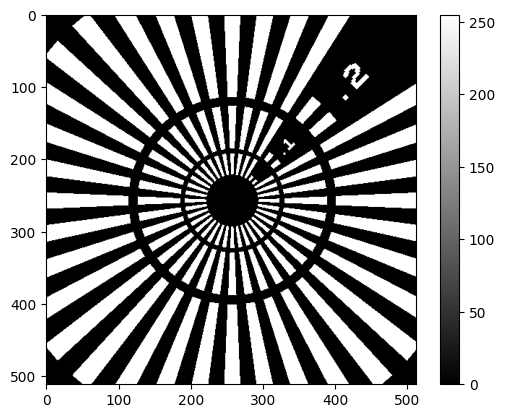

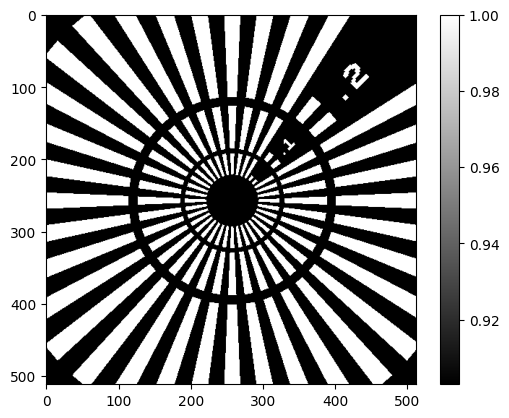

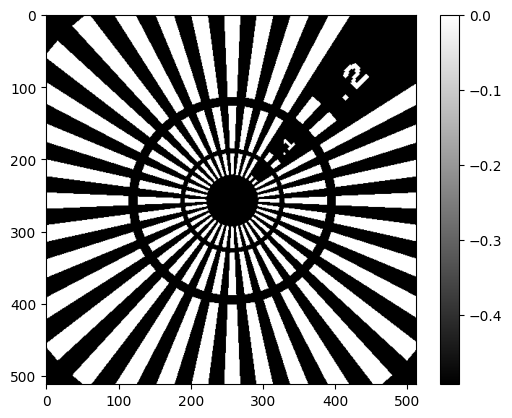

aperture [pix] :  195


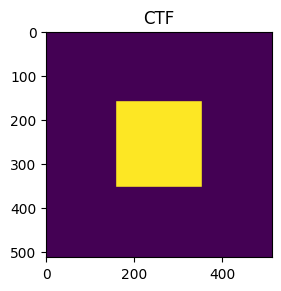

In [9]:
# スターチャート画像の読み込み
img = np.array(Image.open("./50nm_star_512pix.tif"))
plt.imshow(img, cmap="gray")
plt.colorbar()
plt.show()
imax, jmax = img.shape
object_img = (img) / np.max(img)
object_img = np.where(object_img==0 , np.exp(1.0j * 2.0 * np.pi / xlambda * refraction * thickness), 1.0)
obA = np.abs(object_img)
obP = np.angle(object_img)
plt.imshow(obA,cmap="gray")
plt.colorbar()
plt.show()
plt.imshow(obP,cmap="gray")
plt.colorbar()
plt.show()

# 開口サイズの計算
aperture = pixel_size * m * 2.0 * np.tan(NA)/xlambda     # [pixel]
print("aperture [pix] : ", int(aperture))
seq = np.linspace(-1.0*n/aperture, 1.0*n/aperture, int(n))


# 開口マスク作成
CTF = np.zeros((n,m))
CTF[n//2-int(aperture//2) : n//2+int(aperture//2),
    m//2-int(aperture//2) : m//2+int(aperture//2)] = 1.0
plt.subplot(1,2,1)
plt.title("CTF")
plt.imshow(CTF)
plt.show()



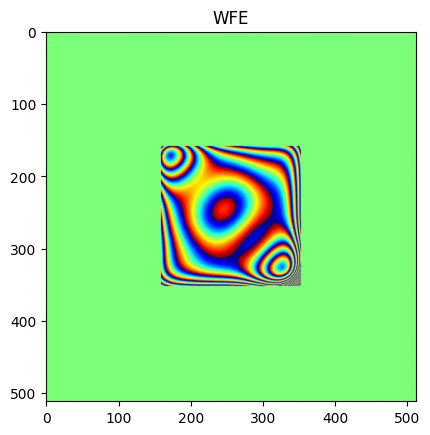

In [10]:
# Legendre波面作成用メッシュグリッド
[x, y] = np.meshgrid(np.linspace(-1.0*n/aperture, 1.0*n/aperture, int(n)), np.linspace(-1.0*m/aperture, 1.0*m/aperture, int(m)))

# Legendre多項式の基底関数
B = Legendre_basis_6(x, y)
coef = [1]*28

# 瞳関数の作成
pupil = np.array(polyEval2D(coef, B)) * CTF
pupil = (np.cos(pupil) + 1.0j*np.sin(pupil)) * CTF
plt.title("WFE")
plt.imshow(np.angle(pupil),cmap="jet")
plt.show()

# 平面波展開用メッシュグリッド（解析時）
dfx = 1.0 / (pixel_size * m)
dfy = 1.0 / (pixel_size * n)
fx = np.arange(-m/2, m/2) * dfx
fy = np.arange(-n/2, n/2) * dfy
fx = tf.constant(fx, dtype=tf.float32)
fy = tf.constant(fy, dtype=tf.float32)
fx_mesh, fy_mesh = tf.meshgrid(fx, fy)
fz2 = 1.0 / xlambda ** 2 - fx_mesh ** 2 - fy_mesh ** 2
fz2 = tf.where(fz2 > 0.0, fz2, 0.0)
fz = tf.sqrt(fz2)



## 評価関数

In [11]:
import scipy.ndimage as ndimage
def ssim_culc2_8(pupil, rot_angle = 45):
    img_list = []
    angle = 2*np.pi/(360/rot_angle)
    angle_num = int(360/rot_angle)

    for i in range(angle_num):
      rot_A = np.array(tfa.rotate(obA, tf.constant(-1.0 * i * angle)))
      rot_P = np.array(tfa.rotate(obP, tf.constant(-1.0 * i * angle)))
      # コヒーレント結像
      object_img = rot_A * np.exp(rot_P * 1j)
      object_imgFT = np.fft.fftshift(np.fft.fft2(object_img))
      imSeqLowFT = object_imgFT * pupil
      exp_field = np.fft.ifft2(np.fft.ifftshift(imSeqLowFT))
      exp_intensity = np.abs(exp_field)**2
      scale = np.max(exp_intensity)
      exp_intensity = photon * exp_intensity/scale
      exp_intensity = np.abs(addGaussianNoise(exp_intensity))
      exp_intensity = exp_intensity/photon*scale
      exp_intensity = np.array(tfa.rotate(exp_intensity, tf.constant(i * angle)))
      img_out = exp_intensity[imax//2-int(363//2) : imax//2+int(363//2),jmax//2-int(363//2) : jmax//2+int(363//2)]
      # img_out = ndimage.median_filter(img_out, size=3)
      img_out = ndimage.gaussian_filter(img_out, sigma=1.0)
      # plt.imshow(img_out,cmap='gray')
      # plt.colorbar()
      # plt.show()
      img_list.append(tf.expand_dims(img_out, axis=-1))
      ssim_list = np.array([])
    for i in range(7):
      ssim = tf.image.ssim(img_list[0], img_list[i+1], max_val=1, filter_size=11, filter_sigma=3, k1=0.01, k2=0.03 )
      ssim_list = np.append(ssim_list, ssim.numpy())
    return float(np.mean(ssim_list))


In [12]:
def ssim_culc2_8(pupil, rot_angle = 45):
    ssim_list = np.array([])
    angle = 2*np.pi/(360/rot_angle)
    rot_A = np.array(tfa.rotate(obA, tf.constant(-1.0 * 0.0)))
    rot_P = np.array(tfa.rotate(obP, tf.constant(-1.0 * 0.0)))
    # コヒーレント結像
    object_img = rot_A * np.exp(rot_P * 1j)
    object_imgFT = np.fft.fftshift(np.fft.fft2(object_img))
    imSeqLowFT = object_imgFT * pupil
    exp_field = np.fft.ifft2(np.fft.ifftshift(imSeqLowFT))
    exp_intensity = np.abs(exp_field)**2
    scale = np.max(exp_intensity)
    exp_intensity = photon * exp_intensity/scale
    exp_intensity = np.abs(addGaussianNoise(exp_intensity))
    exp_intensity = exp_intensity/photon*scale

    #ノイズ除去
    exp_intensity = np.expand_dims(exp_intensity, axis=-1)
    sigma_est = np.mean(estimate_sigma(exp_intensity, channel_axis=-1))

    patch_kw = dict(
        patch_size=5,  # 5x5 patches
        patch_distance=6,  # 13x13 search area
        channel_axis=-1,
    )

    # fast algorithm, sigma provided
    exp_intensity = denoise_nl_means(
        exp_intensity, h=0.6 * sigma_est, sigma=sigma_est, fast_mode=True, **patch_kw
    )

    img_out = exp_intensity[imax//2-int(128//2) : imax//2+int(128//2),jmax//2-int(128//2) : jmax//2+int(128//2)]
    img_out = ndimage.median_filter(img_out, size=3)
    img_culc = tf.expand_dims(img_out, axis=-1)
    # img_out = ndimage.gaussian_filter(img_out, sigma=1.0)
    # plt.imshow(img_out,cmap='gray')
    # plt.colorbar()
    # plt.show()

    rot_A = np.array(tfa.rotate(obA, tf.constant(-1.0 * angle)))
    rot_P = np.array(tfa.rotate(obP, tf.constant(-1.0 * angle)))
    # コヒーレント結像
    object_img = rot_A * np.exp(rot_P * 1j)
    object_imgFT = np.fft.fftshift(np.fft.fft2(object_img))
    imSeqLowFT = object_imgFT * pupil
    exp_field = np.fft.ifft2(np.fft.ifftshift(imSeqLowFT))
    exp_intensity = np.abs(exp_field)**2
    scale = np.max(exp_intensity)
    exp_intensity = photon * exp_intensity/scale
    exp_intensity = np.abs(addGaussianNoise(exp_intensity))
    exp_intensity = exp_intensity/photon*scale

    #ノイズ除去
    exp_intensity = np.expand_dims(exp_intensity, axis=-1)
    sigma_est = np.mean(estimate_sigma(exp_intensity, channel_axis=-1))

    patch_kw = dict(
        patch_size=5,  # 5x5 patches
        patch_distance=6,  # 13x13 search area
        channel_axis=-1,
    )

    # fast algorithm, sigma provided
    exp_intensity = denoise_nl_means(
        exp_intensity, h=0.6 * sigma_est, sigma=sigma_est, fast_mode=True, **patch_kw
    )

    exp_intensity = np.array(tfa.rotate(exp_intensity, tf.constant(angle)))
    img_out2 = exp_intensity[imax//2-int(128//2) : imax//2+int(128//2),jmax//2-int(128//2) : jmax//2+int(128//2)]
    img_out2 = ndimage.median_filter(img_out2, size=3)
    # img_out = ndimage.gaussian_filter(img_out, sigma=1.0)
    img_culc2 = tf.expand_dims(img_out2, axis=-1)
    ssim = tf.image.ssim(img_culc, img_culc2, max_val=1, filter_size=11, filter_sigma=1.5, k1=0.01, k2=0.03 )
    # print(ssim.numpy())
    return ssim.numpy()

In [13]:
def ssim_culc2_8_filter(pupil,rot_angle=20,crop_size=256):
  img_total = np.zeros((crop_size, crop_size))
  angle = 2*np.pi/(360/rot_angle)
  angle_num = int(360/rot_angle)
  img_list = []
  angle_list=[]
  for i in range(angle_num):
    angle_list.append(i*rot_angle)
    rot_A = np.array(tfa.rotate(obA, tf.constant(-1.0 * i * angle)))
    rot_P = np.array(tfa.rotate(obP, tf.constant(-1.0 * i * angle)))
    # コヒーレント結像
    object_img = rot_A * np.exp(rot_P * 1j)
    object_imgFT = np.fft.fftshift(np.fft.fft2(object_img))
    imSeqLowFT = object_imgFT * pupil
    exp_field = np.fft.ifft2(np.fft.ifftshift(imSeqLowFT))

    # 面ブレを考慮したデフォーカスを与える．
    dz = -40.0 *1e-6
    exp_field = ASM_tf(exp_field, pixel_size, dz, xlambda)


    exp_intensity = np.abs(exp_field)**2
    scale = np.max(exp_intensity)
    exp_intensity = photon * exp_intensity/scale
    exp_intensity = np.abs(addGaussianNoise(exp_intensity))
    exp_intensity = exp_intensity/photon*scale

    # exp_intensity = ndimage.median_filter(exp_intensity)

    #ノイズ除去
    exp_intensity = np.expand_dims(exp_intensity, axis=-1)
    sigma_est = np.mean(estimate_sigma(exp_intensity, channel_axis=-1))

    patch_kw = dict(
        patch_size=5,  # 5x5 patches
        patch_distance=6,  # 13x13 search area
        channel_axis=-1,
    )

    # fast algorithm, sigma provided
    exp_intensity = denoise_nl_means(
        exp_intensity, h=0.6 * sigma_est, sigma=sigma_est, fast_mode=True, **patch_kw
    )

    exp_intensity = np.array(tfa.rotate(exp_intensity, tf.constant(i * angle)))
    img_out = exp_intensity[imax//2-int(crop_size//2) : imax//2+int(crop_size//2),
                            jmax//2-int(crop_size//2) : jmax//2+int(crop_size//2)]
    img_list.append(img_out)
    img_out /= np.max(img_out)
    img_total += img_out
  img_total /= angle_num
  # plt.imshow(img_total, cmap="gray")
  # plt.colorbar()
  # plt.show()


  #スコアの計算
  score_list=[]
  img_total_culc = tf.expand_dims(img_total, axis=-1)

  for img in img_list:
    img_culc = tf.expand_dims(img, axis=-1)
    score = tf.image.ssim(img_total_culc, img_culc, max_val=1, filter_size=11, filter_sigma=1.5, k1=0.01, k2=0.03)
    score_list.append(score.numpy())
  score_arr = np.array(score_list)
  score_sigma = np.std(score_arr)
  return np.mean(score_list)

  #コントラスト計算
  # img_dif = cv2.Laplacian(img_total, cv2.CV_64F)
  # cont = np.std(np.abs(img_dif))
  # return cont



In [14]:
def laplacian_score(img):
  img_diff = cv2.Laplacian(img, cv2.CV_32F)
  score = np.std(np.abs(img_diff))
  return score

In [15]:
colors = ['blue'] * 28
colors[3], colors[5] = 'red','red'
colors[6], colors[9] = 'blue', 'blue'
colors[10], colors[14] = 'green', 'green'
colors[15], colors[20] = 'yellow', 'yellow'
colors[21], colors[27] = 'purple', 'purple'

In [16]:
# colors = ['blue'] * 21
# colors[3], colors[5] = 'red','red'
# colors[6], colors[9] = 'blue', 'blue'
# colors[10], colors[14] = 'green', 'green'
# colors[15], colors[20] = 'yellow', 'yellow'

# PSO


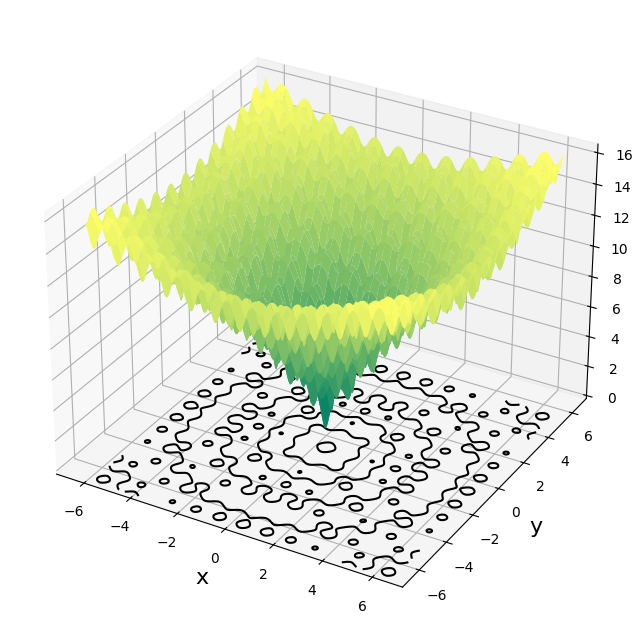

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 目的関数
def objective_function(X,Y):
    t1 = 20
    t2 = -20 * np.exp(-0.2 * np.sqrt(1.0 / 2 * (X**2 + Y**2 )))
    t3 = np.e
    t4 = -np.exp(1.0 / 2 * (np.cos(2 * np.pi * X)+np.cos(2 * np.pi * Y)))
    return t1 + t2 + t3 + t4

# Figureと3DAxeS
fig = plt.figure(figsize = (8, 8))
ax = fig.add_subplot(111, projection="3d")

# 軸ラベルを設定
ax.set_xlabel("x", size = 16)
ax.set_ylabel("y", size = 16)
ax.set_zlabel("z", size = 16)

# 円周率の定義
pi = np.pi

# (x,y)データを作成
x = np.linspace(-2*pi, 2*pi, 256)
y = np.linspace(-2*pi, 2*pi, 256)

# 格子点を作成
X_p, Y_p = np.meshgrid(x, y)
Z = objective_function(X_p,Y_p)

# # 曲面を描画
ax.plot_surface(X_p, Y_p, Z, cmap = "summer")

# # 底面に等高線を描画
ax.contour(X_p, Y_p, Z, colors = "black", offset = -1)

plt.show()


X:[[-8.16279327e-02 -6.76748305e-01  1.23254788e-01 -6.17717983e-01
   5.49911513e-01  7.31090332e-01  2.61451898e-01 -2.24310299e+00
  -2.91460201e+00 -9.57855953e-01  1.36987194e-01  6.43494732e-01
  -3.80626374e-01 -1.52682986e+00 -2.47427540e+00 -4.67227545e-01
  -2.55795858e+00 -1.94601579e-03 -1.58325790e-01  1.33548057e-01
  -2.66017859e+00  5.18179585e-01 -1.96625105e+00  7.41550882e-01
  -2.16763235e+00 -1.33764292e+00 -7.82346859e-01 -1.95737022e+00
  -8.73791951e-01 -2.95586079e+00 -2.37131873e+00 -1.40129886e+00
   2.45018194e-01  2.52015496e-01 -5.89202213e-01 -2.71478616e+00
  -2.11382553e-01  5.77551838e-01 -1.33265446e+00  6.11590445e-01
  -1.37366114e+00 -2.50329814e+00  7.86582638e-02 -1.71537826e+00
  -1.22272280e+00 -2.59238258e+00 -1.58978980e+00 -2.22940215e+00
   2.97596301e-02 -2.66707327e+00 -1.37580686e+00 -6.62566214e-01
  -2.58369210e+00 -2.23519382e+00 -4.76703347e-01 -3.45751597e-01
  -1.08057692e+00 -2.74980685e+00 -3.83807504e-01  3.47837865e-01
  -1.217

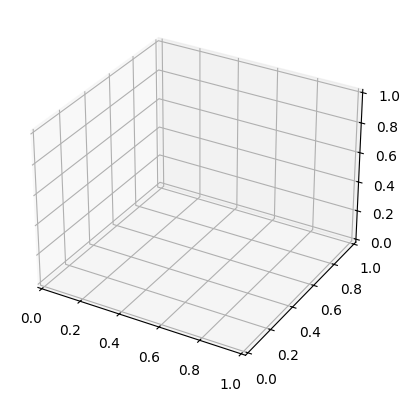

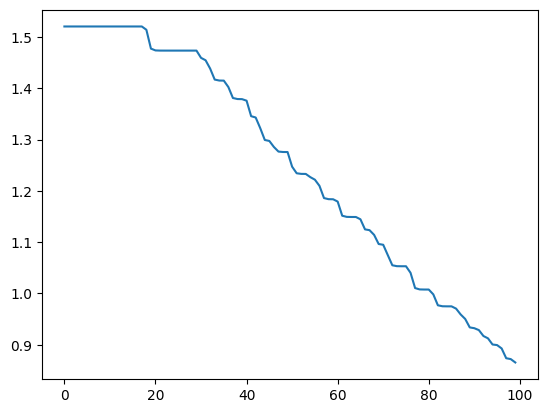

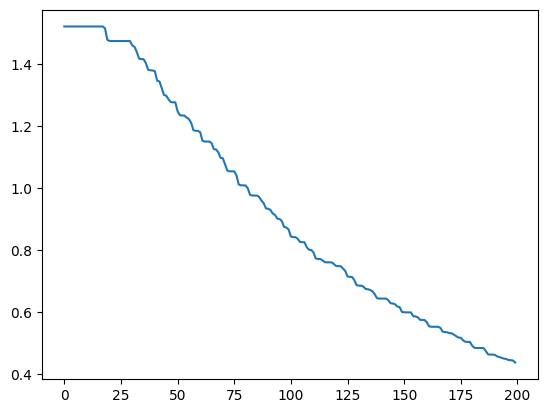

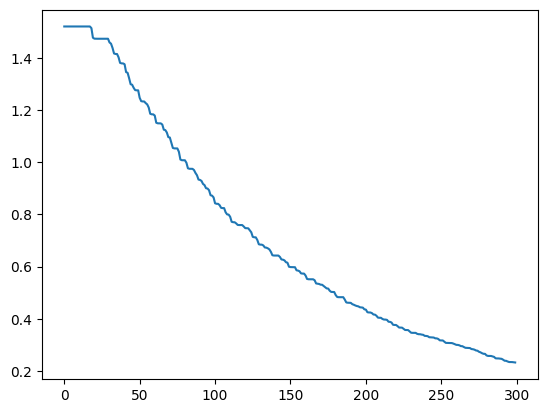

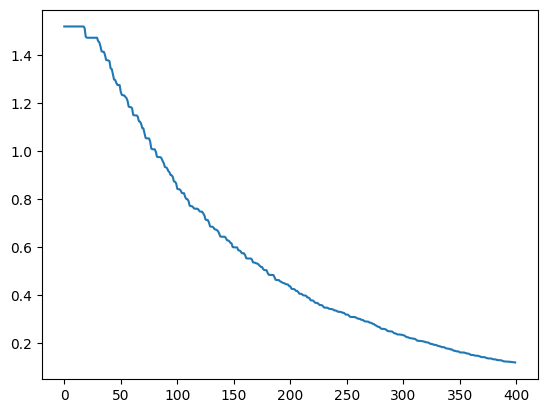

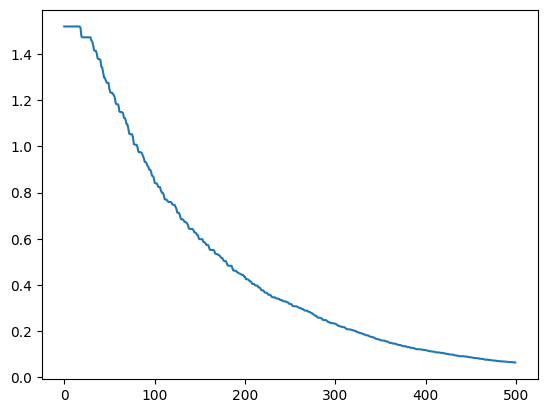

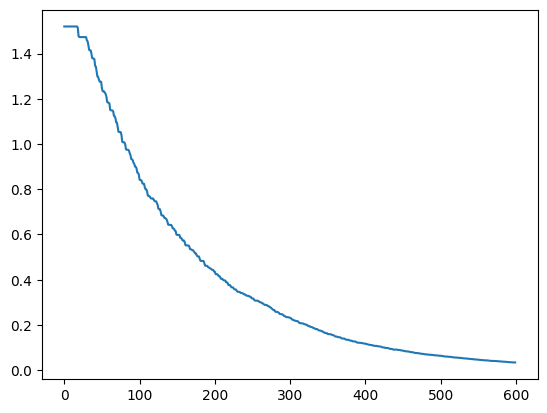

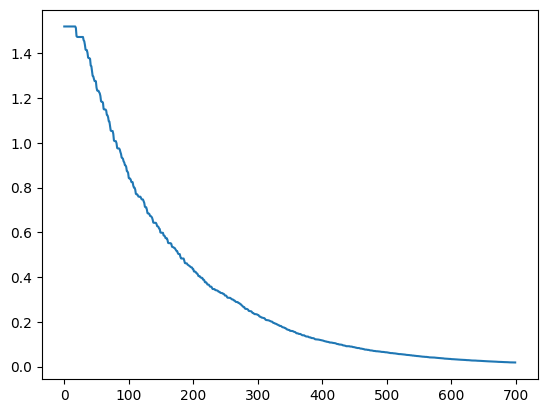

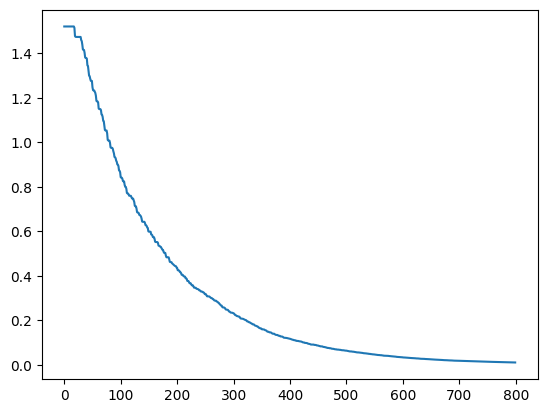

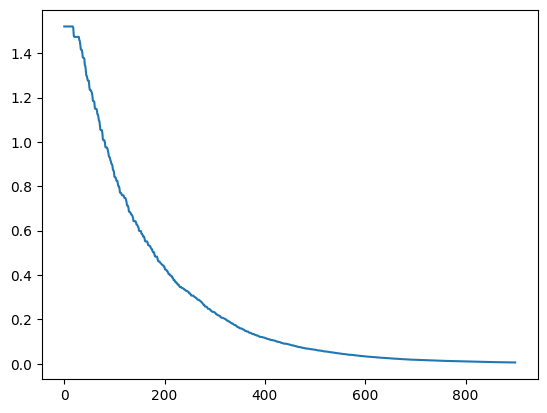

[-0.00093669 -0.00070738  0.00335667]


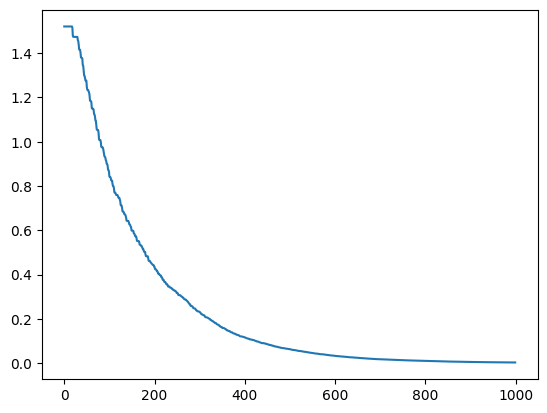

In [23]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

dim = 2

#初期化
N = 100 #粒子数
max_iter = 1000
X = 4*np.random.rand(dim, N) - 3*np.ones((dim, N))
V = 0.2*np.random.rand(dim, N) - 0.1*np.ones((dim, N))
print(f'X:{X}')
print(f'V:{V}')
Z_plain = np.zeros((1,N))
pbest = np.zeros((3,N))
pbest[0:2,:] = X
Zinit = objective_function(pbest[0,:],pbest[1,:])
pbest[2,:] = Zinit
#初期化した粒子の内で最も良いものをgbestとして格納
ap = np.argmin(Zinit)
gbest = np.array([pbest[0,ap],pbest[1,ap],objective_function(pbest[0,ap],pbest[1,ap])])

w = 0.1
c1 = 0.01
c2 = 0.01
res = np.zeros((dim,max_iter))
for i in range(max_iter):
  # N個分の粒子をfor文で計算
  for j in range(N):
    #位置の更新
    X[:,j] = X[:,j] + V[:,j]
    #速度の更新
    V[:,j] = w*V[:,j] + c1*np.random.rand(1)*(pbest[0:dim,j]-X[:,j]) +c2*np.random.rand(1)*(gbest[0:2]-X[:,j])
    if  objective_function(X[0,j],X[1,j]) < pbest[2,j]:
       pbest[0:2,j] = X[:,j]
       pbest[2,j] = objective_function(X[0,j],X[1,j])
  # N個の粒子の内で最適なものを取得し，過去の最適値と比較する
  a = np.argmin(pbest[2,:])
  if pbest[2,a] < gbest[2]:
    gbest[0:2] = pbest[0:2,a]
    gbest[2] = objective_function(gbest[0],gbest[1])

  #イタレーション回数iとその際の最適値を格納
  res[:,i] = np.array([i,gbest[2]])
  if np.mod(i,100) == 0:
    plt.plot(res[0,0:i],res[1,0:i])
    plt.show()


plt.plot(res[0,:],res[1,:])
print(gbest)


  1%|          | 1/100 [00:04<07:03,  4.28s/it]

start:[0.060838797473020456, -1.606240171109948, 1.1669275484655026, 0.5247501172357922, 0.04127043596092905, -1.0420534159896002, -0.022831235631330493, 0.276852973537165]


100%|██████████| 100/100 [07:04<00:00,  4.25s/it]

Global best position:  [0.025848339828697692, 0.03180764533789664, 0.009764905995598538, 0.003339355311361385, -0.03885849784136109, -0.03662459160503546, 0.0010728918329064026, -0.008481327323205773]
Global best fitness:  0.044467524


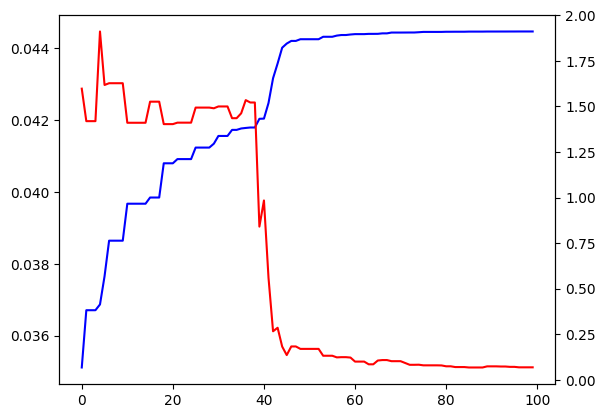

main took 424.79400 seconds


In [79]:
import random
import math
from tqdm import tqdm

import pygame
from pygame.locals import *

pygame.init()
SCREEN_WIDTH = 800
SCREEN_HEIGHT = 600
BACKGROUND_COLOR = (255, 255, 255)
PARTICLE_COLOR = (0, 0, 0)
PARTICLE_RADIUS = 5

screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))
pygame.display.set_caption("Particle Swarm Optimization")


class Particle:
    def __init__(self, num_variables, bounds):
        self.position = [random.uniform(
            bounds[i][0], bounds[i][1]) for i in range(num_variables)]
        self.velocity = [random.uniform(-0.5, 0.5) for _ in range(num_variables)]
        self.best_position = self.position[:]
        self.best_fitness = 0.0

        self.hash = hash(tuple(self.velocity) +
                         tuple(random.random() for _ in range(10)))

    def evaluate(self):
        coef = [0.0]*28
        coef[3], coef[5], coef[6], coef[9], coef[10], coef[14], coef[15], coef[20], = self.position #coef[21], coef[27]
        phase_img = phase_imaging(coef)
        fitness = laplacian_score(phase_img)
        rms = rms_calculate(make_wavefront(coef))
        return fitness, rms


class PSO:
    def __init__(self, num_particles, num_variables, bounds, max_iterations):
        self.inertia_weight = 0.7
        self.cognitive_weight = 1.5
        self.social_weight = 1.75
        self.num_particles = num_particles
        self.num_variables = num_variables
        self.bounds = bounds
        self.max_iterations = max_iterations
        self.global_best_position = [2.0] * num_variables
        self.global_best_fitness = 0.0
        self.global_best_rms = None
        self.particles = [Particle(num_variables, bounds)
                          for _ in range(num_particles)]

        self.history = {particle.hash: [particle.position[:]]
                        for particle in self.particles}

        self.history[hash('global_best')] = [
            self.global_best_position[:]]

        self.iteration_used = 0
        self.blur_history = []
        self.rms_history = []

    def optimize(self):
        for i in tqdm(range(self.max_iterations)):
            for particle in self.particles:
                fitness, rms = particle.evaluate()
                if fitness > particle.best_fitness:
                    particle.best_fitness = fitness
                    particle.best_position = particle.position[:]
                if fitness > self.global_best_fitness:
                    self.global_best_fitness = fitness
                    self.global_best_rms = rms
                    self.global_best_position = particle.position[:]
                    self.history[hash('global_best')].append(
                        particle.position[:])
            if i == 0:
              print(f'start:{self.global_best_position}')
            self.blur_history.append(self.global_best_fitness)
            self.rms_history.append(self.global_best_rms)

            for particle in self.particles:
                for i in range(self.num_variables):
                    r1, r2 = random.random(), random.random()
                    particle.velocity[i] = (self.inertia_weight * particle.velocity[i] +
                                            self.cognitive_weight * r1 * (particle.best_position[i] - particle.position[i]) +
                                            self.social_weight * r2 * (self.global_best_position[i] - particle.position[i]))
                    particle.position[i] += particle.velocity[i]
                    if abs(particle.position[i]) > 2.0:
                       particle.position[i] = random.uniform(-2, 2)
                self.history[particle.hash].append(particle.position[:])

            self.iteration_used += 1


def draw(history, hash_key, iteration, color=PARTICLE_COLOR):
    if iteration >= len(history[hash_key]):
        return
    particle_position_at_iteration = history[hash_key][iteration]
    pygame.draw.circle(screen, color, (int(particle_position_at_iteration[0] * 10 + SCREEN_WIDTH / 2),
                                       int(particle_position_at_iteration[1] * 10 + SCREEN_HEIGHT / 2)), PARTICLE_RADIUS)

@timer
def main():
    num_particles = 40
    num_variables = 8
    bounds = [[-2, 2]] * num_variables
    max_iterations = 100


    optimizer = PSO(num_particles, num_variables, bounds, max_iterations)

    optimizer.optimize()

    print("Global best position: ", optimizer.global_best_position)
    print("Global best fitness: ", optimizer.global_best_fitness)

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(optimizer.blur_history, color='blue')
    ax2.plot(optimizer.rms_history, color='red')
    plt.show()


if __name__ == "__main__":
    main()

In [62]:
N = 4

coef_w = 4     # Legendre多項式の係数幅
limit = coef_w/2
maxD    = 6                    # Legendre多項式の最大次数
mode = (maxD+1)*(maxD+2)//2     # Legendre modeの数
print("Legendre dimension, mode : ", str(maxD) + ", " + str(mode))

target = [random.uniform(0.0, coef_w)-coef_w/2 for i in range(N)]   # Legendre多項式の係数
coef = [0.0] * mode

res_coef = target

print(res_coef)


Legendre dimension, mode :  6, 28
[0.14915648606798504, -1.708036242394317, 0.974056881212618, 0.4656803393119362]


  2%|▏         | 1/50 [00:01<00:54,  1.11s/it]

start:[0.8469808208362051, 1.1693824077743238, 1.9191704006659784, 0.6389808854880896, 1.2569463127600748, -1.365482158482339]


100%|██████████| 50/50 [00:55<00:00,  1.12s/it]

Global best position:  [0.7915720676989644, -0.4688488358956875, -0.7694718466560413, -0.5506317139501462, 0.43679413412268736, -0.12495249130453556]
Global best fitness:  0.035808127


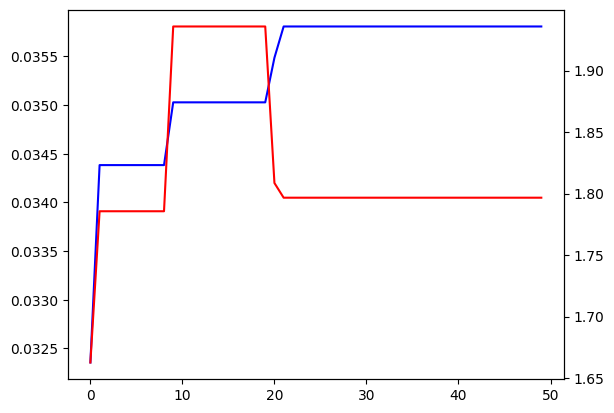

In [64]:
class Particle:
    def __init__(self, num_variables, bounds):
        self.position = [random.uniform(
            bounds[i][0], bounds[i][1]) for i in range(num_variables)]
        self.velocity = [random.uniform(-1, 1) for _ in range(num_variables)]
        self.best_position = self.position[:]
        self.best_fitness = 0.0

        self.hash = hash(tuple(self.velocity) +
                         tuple(random.random() for _ in range(10)))

    def evaluate(self):
        global coef
        coef = [0.0]*28

        coef[6], coef[9], coef[15],coef[20] = res_coef

        coef[3], coef[5], coef[10], coef[14], coef[21], coef[27] = self.position #coef[20],coef[3], coef[5], coef[6], coef[9], coef[10], coef[14], coef[15], coef[20], coef[21], coef[27]
        phase_img = phase_imaging(coef)
        fitness = laplacian_score(phase_img)
        rms = rms_calculate(make_wavefront(coef))
        return fitness, rms

def main():
    num_particles = 10
    num_variables = 6
    bounds = [[-2, 2]] * num_variables
    max_iterations = 50

    optimizer = PSO(num_particles, num_variables, bounds, max_iterations)
    optimizer.optimize()

    print("Global best position: ", optimizer.global_best_position)
    print("Global best fitness: ", optimizer.global_best_fitness)

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(optimizer.blur_history, color='blue')
    ax2.plot(optimizer.rms_history, color='red')
    plt.show()


if __name__ == "__main__":
    main()

In [65]:
res_coef = [0.7915720676989644, -0.4688488358956875, -0.7694718466560413, -0.5506317139501462, 0.43679413412268736, -0.12495249130453556]

  2%|▏         | 1/50 [00:01<00:54,  1.12s/it]

start:[0.71636938032829, 0.019348714457920746, 1.815608879723206, -0.2906294853509479]


100%|██████████| 50/50 [00:54<00:00,  1.10s/it]

Global best position:  [0.05117020596218626, 0.5170213339858701, 0.03687939245679117, 0.4159498806258636]
Global best fitness:  0.037893593


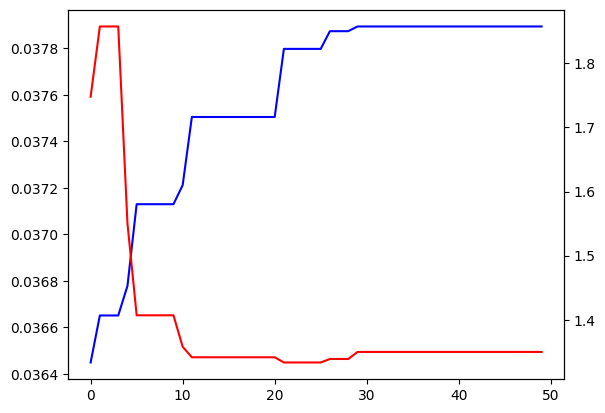

In [66]:
class Particle:
    def __init__(self, num_variables, bounds):
        self.position = [random.uniform(
            bounds[i][0], bounds[i][1]) for i in range(num_variables)]
        self.velocity = [random.uniform(-1, 1) for _ in range(num_variables)]
        self.best_position = self.position[:]
        self.best_fitness = 0.0

        self.hash = hash(tuple(self.velocity) +
                         tuple(random.random() for _ in range(10)))

    def evaluate(self):
        global coef
        coef = [0.0]*28

        coef[3], coef[5], coef[10], coef[14], coef[21], coef[27] = res_coef

        coef[6], coef[9], coef[15],coef[20]  = self.position #coef[20],coef[3], coef[5], coef[6], coef[9], coef[10], coef[14], coef[15], coef[20], coef[21], coef[27]
        phase_img = phase_imaging(coef)
        fitness = laplacian_score(phase_img)
        rms = rms_calculate(make_wavefront(coef))
        return fitness, rms

def main():
    num_particles = 10
    num_variables = 4
    bounds = [[-2, 2]] * num_variables
    max_iterations = 50

    optimizer = PSO(num_particles, num_variables, bounds, max_iterations)
    optimizer.optimize()

    print("Global best position: ", optimizer.global_best_position)
    print("Global best fitness: ", optimizer.global_best_fitness)

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(optimizer.blur_history, color='blue')
    ax2.plot(optimizer.rms_history, color='red')
    plt.show()


if __name__ == "__main__":
    main()

In [67]:
print(coef)

[0.0, 0.0, 0.0, 0.7915720676989644, 0.0, -0.4688488358956875, 0.4386594459140065, 0.0, 0.0, -0.14508754215464048, -0.7694718466560413, 0.0, 0.0, 0.0, -0.5506317139501462, 0.3485091838196134, 0.0, 0.0, 0.0, 0.0, -0.10851846517875918, 0.43679413412268736, 0.0, 0.0, 0.0, 0.0, 0.0, -0.12495249130453556]


In [68]:
res_coef = coef[6], coef[9], coef[15],coef[20]

  2%|▏         | 1/50 [00:01<00:54,  1.10s/it]

start:[-0.5092172652583926, -0.8038843274089373, -0.6762088210059876, 1.0813069507531923, -0.11329125943400964, -0.5567346520532128]


100%|██████████| 50/50 [00:55<00:00,  1.11s/it]

Global best position:  [0.10969374259264267, -0.9748962610412347, 0.08547299225874319, 0.6610896086275543, 0.0016324912486007648, -0.13209693068349626]
Global best fitness:  0.038973834


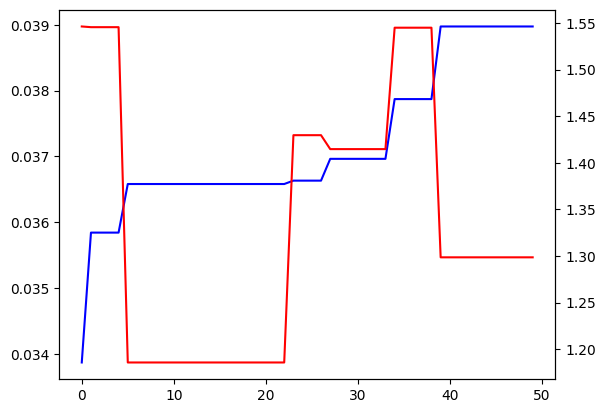

In [69]:
class Particle:
    def __init__(self, num_variables, bounds):
        self.position = [random.uniform(
            bounds[i][0], bounds[i][1]) for i in range(num_variables)]
        self.velocity = [random.uniform(-1, 1) for _ in range(num_variables)]
        self.best_position = self.position[:]
        self.best_fitness = 0.0

        self.hash = hash(tuple(self.velocity) +
                         tuple(random.random() for _ in range(10)))

    def evaluate(self):
        global coef
        coef = [0.0]*28

        coef[6], coef[9], coef[15],coef[20] = res_coef

        coef[3], coef[5], coef[10], coef[14], coef[21], coef[27] = self.position #coef[20],coef[3], coef[5], coef[6], coef[9], coef[10], coef[14], coef[15], coef[20], coef[21], coef[27]
        phase_img = phase_imaging(coef)
        fitness = laplacian_score(phase_img)
        rms = rms_calculate(make_wavefront(coef))
        return fitness, rms

def main():
    num_particles = 10
    num_variables = 6
    bounds = [[-2, 2]] * num_variables
    max_iterations = 50

    optimizer = PSO(num_particles, num_variables, bounds, max_iterations)
    optimizer.optimize()

    print("Global best position: ", optimizer.global_best_position)
    print("Global best fitness: ", optimizer.global_best_fitness)

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(optimizer.blur_history, color='blue')
    ax2.plot(optimizer.rms_history, color='red')
    plt.show()


if __name__ == "__main__":
    main()

In [70]:
print(coef)

[0.0, 0.0, 0.0, -1.5518053169579313, 0.0, -0.38008894464348486, 0.4386594459140065, 0.0, 0.0, -0.14508754215464048, -0.3219906907351674, 0.0, 0.0, 0.0, -1.3755030176760068, 0.3485091838196134, 0.0, 0.0, 0.0, 0.0, -0.10851846517875918, 0.802584465238701, 0.0, 0.0, 0.0, 0.0, 0.0, -1.4053974324180243]


## 縦横別々

Legendre dimension, mode :  6, 28
[0.0, 0.0, 0.0, 1.8171441765225045, 0.0, -0.777825985845622, -0.3529963489399761, 0.0, 0.0, 0.02391286561467476, 1.3055244103942725, 0.0, 0.0, 0.0, -1.639054716843273, -0.2039471231736436, 0.0, 0.0, 0.0, 0.0, 0.42105233265397723, 0.33778328810236236, 0.0, 0.0, 0.0, 0.0, 0.0, 0.47460272533152636]


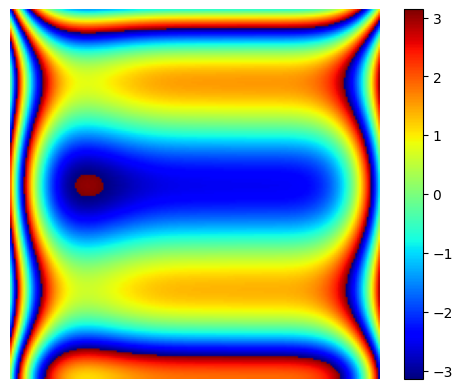

In [190]:
N = 10

coef_w = 4     # Legendre多項式の係数幅
limit = coef_w/2
maxD    = 6                    # Legendre多項式の最大次数
mode = (maxD+1)*(maxD+2)//2     # Legendre modeの数
print("Legendre dimension, mode : ", str(maxD) + ", " + str(mode))

target = [random.uniform(0.0, coef_w)-coef_w/2 for i in range(N)]   # Legendre多項式の係数
coef = [0.0] * mode
coef[3], coef[5], coef[6], coef[9], coef[10], coef[14], coef[15], coef[20], coef[21], coef[27] = target

print(coef)
pupil = make_wavefront(coef)
angle_pupil = np.angle(pupil[imax//2-int(aperture//2):imax//2+int(aperture//2),imax//2-int(aperture//2):imax//2+int(aperture//2)])
plt.imshow(angle_pupil, cmap='jet', vmin=-np.pi, vmax=np.pi)
plt.axis('off')
plt.colorbar()
plt.show()

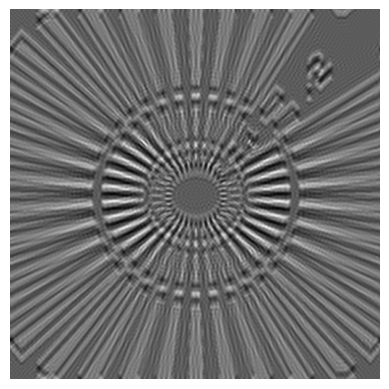

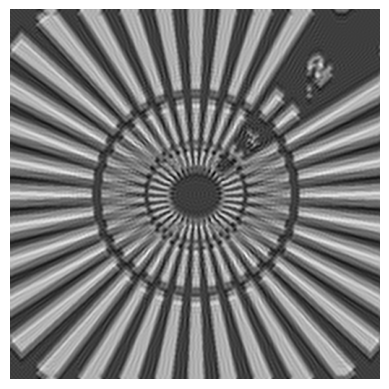

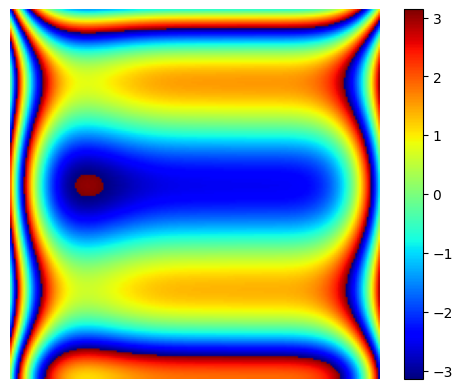

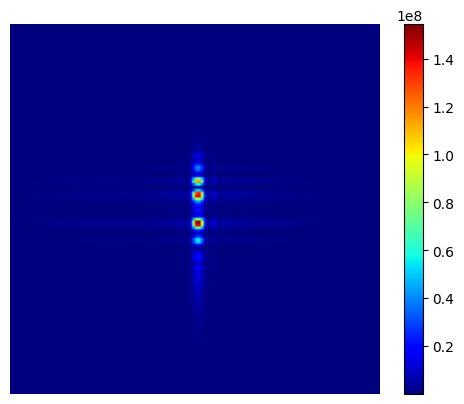

1.654098804252902


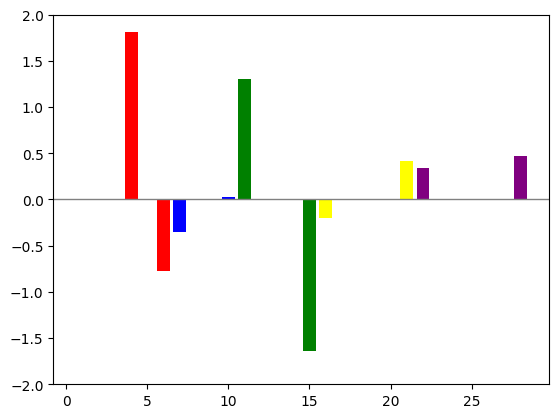

In [191]:
intensity, phage = imaging(coef)

plt.imshow(intensity, cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(phage, cmap='gray')
plt.axis('off')
plt.show()


pupil = make_wavefront(coef)
angle_pupil = np.angle(pupil[imax//2-int(aperture//2):imax//2+int(aperture//2),imax//2-int(aperture//2):imax//2+int(aperture//2)])
plt.imshow(angle_pupil, cmap='jet', vmin=-np.pi, vmax=np.pi)
plt.axis('off')
plt.colorbar()
plt.show()


psf_img = psf(pupil)
plt.imshow(psf_img[imax//2-int(128//2) : imax//2+int(128//2),
                                jmax//2-int(128//2) : jmax//2+int(128//2)], cmap='jet')
plt.colorbar()
plt.axis('off')
plt.show()

print(rms_calculate(pupil))
rms_start.append(rms_calculate(pupil))
plt.bar(range(1, 1+len(coef)), coef, color=colors)
plt.ylim(-2.0,2.0)
plt.axhline(y=0, color='gray', linestyle='-', linewidth=1)
plt.show()

  2%|▏         | 1/50 [00:02<01:45,  2.15s/it]

start:[-1.8178333022404707, 0.08612037424800123, -1.017820436329235, 0.7407610801542592, -0.34225339074900063]


100%|██████████| 50/50 [01:45<00:00,  2.11s/it]

Global best position:  [-0.6593231693587472, 0.540472374328131, -0.5135504983990431, 0.3424637376086177, -0.26335159681366094]
Global best fitness:  0.27595568


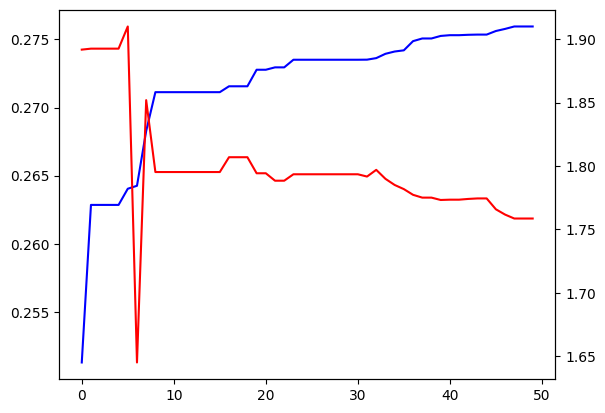

main took 105.57666 seconds


In [192]:
import random
import math
from tqdm import tqdm


class Particle:
    def __init__(self, num_variables, bounds):
        self.position = [random.uniform(
            bounds[i][0], bounds[i][1]) for i in range(num_variables)]
        self.velocity = [random.uniform(-0.5, 0.5) for _ in range(num_variables)]
        self.best_position = self.position[:]
        self.best_fitness = 0.0

        self.hash = hash(tuple(self.velocity) +
                         tuple(random.random() for _ in range(10)))

    def evaluate(self):
        global coef
        coef[3], coef[6], coef[10], coef[15], coef[21]= self.position #
        phase_img = phase_imaging(coef)
        phase_img_diff = cv2.Sobel(phase_img, cv2.CV_32F, 1, 0, ksize=3)
        phase_img_diff = np.abs(phase_img_diff)
        fitness = np.std(phase_img_diff)
        rms = rms_calculate(make_wavefront(coef))
        return fitness, rms


class PSO:
    def __init__(self, num_particles, num_variables, bounds, max_iterations):
        self.inertia_weight = 0.7
        self.cognitive_weight = 1.5
        self.social_weight = 1.5
        self.num_particles = num_particles
        self.num_variables = num_variables
        self.bounds = bounds
        self.max_iterations = max_iterations
        self.global_best_position = [2.0] * num_variables
        self.global_best_fitness = 0.0
        self.global_best_rms = None
        self.particles = [Particle(num_variables, bounds)
                          for _ in range(num_particles)]

        self.history = {particle.hash: [particle.position[:]]
                        for particle in self.particles}

        self.history[hash('global_best')] = [
            self.global_best_position[:]]

        self.iteration_used = 0
        self.blur_history = []
        self.rms_history = []

    def optimize(self):
        for i in tqdm(range(self.max_iterations)):
            for particle in self.particles:
                fitness, rms = particle.evaluate()
                if fitness > particle.best_fitness:
                    particle.best_fitness = fitness
                    particle.best_position = particle.position[:]
                if fitness > self.global_best_fitness:
                    self.global_best_fitness = fitness
                    self.global_best_rms = rms
                    self.global_best_position = particle.position[:]
                    self.history[hash('global_best')].append(
                        particle.position[:])
            if i == 0:
              print(f'start:{self.global_best_position}')
            self.blur_history.append(self.global_best_fitness)
            self.rms_history.append(self.global_best_rms)

            for particle in self.particles:
                for i in range(self.num_variables):
                    r1, r2 = random.random(), random.random()
                    particle.velocity[i] = (self.inertia_weight * particle.velocity[i] +
                                            self.cognitive_weight * r1 * (particle.best_position[i] - particle.position[i]) +
                                            self.social_weight * r2 * (self.global_best_position[i] - particle.position[i]))
                    particle.position[i] += particle.velocity[i]
                    if abs(particle.position[i]) > 2.0:
                       particle.position[i] = random.uniform(-2, 2)
                self.history[particle.hash].append(particle.position[:])

            self.iteration_used += 1


def draw(history, hash_key, iteration, color=PARTICLE_COLOR):
    if iteration >= len(history[hash_key]):
        return
    particle_position_at_iteration = history[hash_key][iteration]
    pygame.draw.circle(screen, color, (int(particle_position_at_iteration[0] * 10 + SCREEN_WIDTH / 2),
                                       int(particle_position_at_iteration[1] * 10 + SCREEN_HEIGHT / 2)), PARTICLE_RADIUS)

@timer
def main():
    num_particles = 20
    num_variables = 5
    bounds = [[-2, 2]] * num_variables
    max_iterations = 50


    optimizer = PSO(num_particles, num_variables, bounds, max_iterations)

    optimizer.optimize()

    print("Global best position: ", optimizer.global_best_position)
    print("Global best fitness: ", optimizer.global_best_fitness)

    coef[3], coef[6], coef[10], coef[15], coef[21] = optimizer.global_best_position
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(optimizer.blur_history, color='blue')
    ax2.plot(optimizer.rms_history, color='red')
    plt.show()


if __name__ == "__main__":
    main()

In [193]:
print(coef)

[0.0, 0.0, 0.0, -0.6593231693587472, 0.0, -0.777825985845622, 0.540472374328131, 0.0, 0.0, 0.02391286561467476, -0.5135504983990431, 0.0, 0.0, 0.0, -1.639054716843273, 0.3424637376086177, 0.0, 0.0, 0.0, 0.0, 0.42105233265397723, -0.26335159681366094, 0.0, 0.0, 0.0, 0.0, 0.0, 0.47460272533152636]


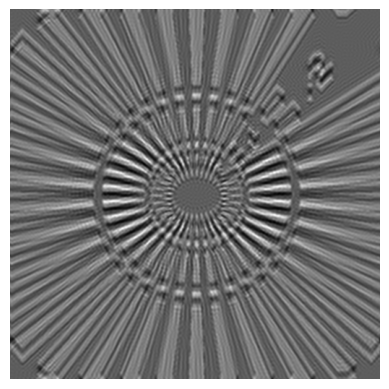

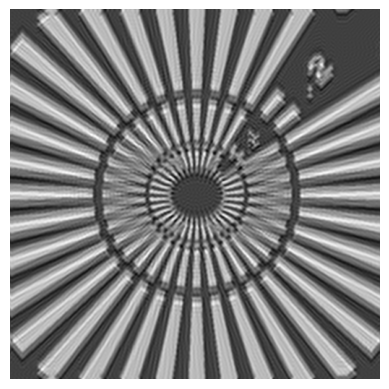

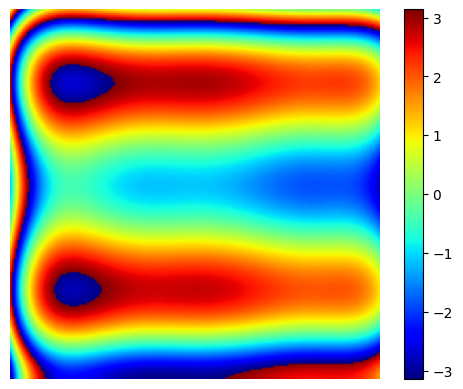

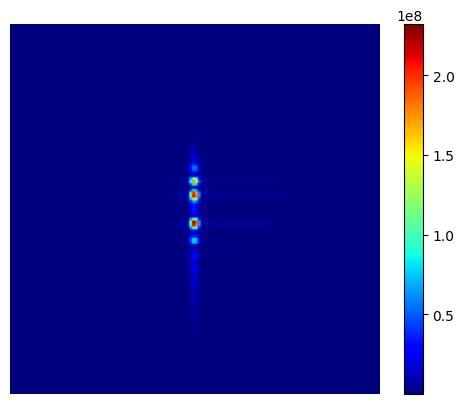

1.7585736518952926


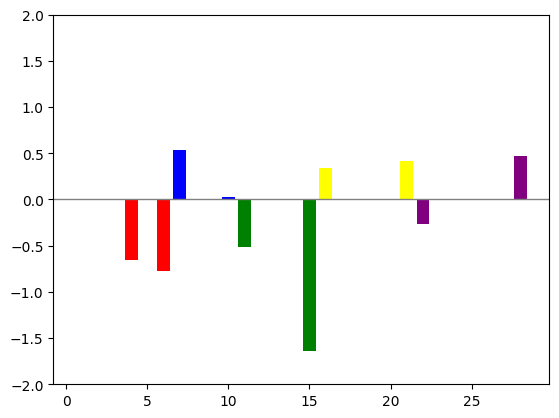

In [194]:
intensity, phage = imaging(coef)

plt.imshow(intensity, cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(phage, cmap='gray')
plt.axis('off')
plt.show()


pupil = make_wavefront(coef)
angle_pupil = np.angle(pupil[imax//2-int(aperture//2):imax//2+int(aperture//2),imax//2-int(aperture//2):imax//2+int(aperture//2)])
plt.imshow(angle_pupil, cmap='jet', vmin=-np.pi, vmax=np.pi)
plt.axis('off')
plt.colorbar()
plt.show()


psf_img = psf(pupil)
plt.imshow(psf_img[imax//2-int(128//2) : imax//2+int(128//2),
                                jmax//2-int(128//2) : jmax//2+int(128//2)], cmap='jet')
plt.colorbar()
plt.axis('off')
plt.show()

print(rms_calculate(pupil))
plt.bar(range(1, 1+len(coef)), coef, color=colors)
plt.ylim(-2.0,2.0)
plt.axhline(y=0, color='gray', linestyle='-', linewidth=1)
plt.show()

  2%|▏         | 1/50 [00:02<01:40,  2.05s/it]

start:[0.23691356421190513, 0.023768987597336366, 0.07886103817819734, 0.20368159394376528, -0.27641350830324596]


100%|██████████| 50/50 [01:42<00:00,  2.06s/it]

Global best position:  [0.10963556506030976, 0.006683627935974583, -0.05987094815052471, -0.006732057953323125, 0.09379942199683922]
Global best fitness:  0.041542705


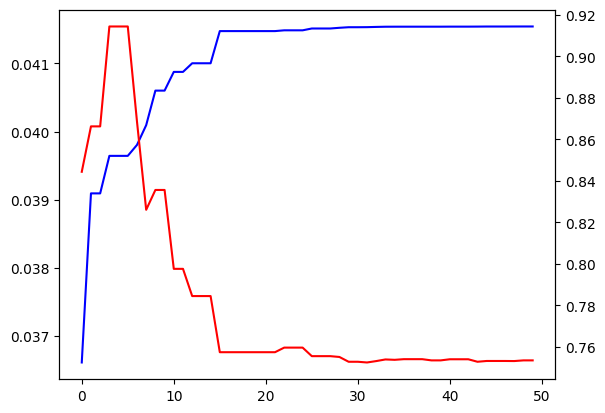

main took 103.01569 seconds


In [195]:
import random
import math
from tqdm import tqdm

import pygame
from pygame.locals import *

pygame.init()
SCREEN_WIDTH = 800
SCREEN_HEIGHT = 600
BACKGROUND_COLOR = (255, 255, 255)
PARTICLE_COLOR = (0, 0, 0)
PARTICLE_RADIUS = 5

screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))
pygame.display.set_caption("Particle Swarm Optimization")


class Particle:
    def __init__(self, num_variables, bounds):
        self.position = [random.uniform(
            bounds[i][0], bounds[i][1]) for i in range(num_variables)]
        self.velocity = [random.uniform(-0.5, 0.5) for _ in range(num_variables)]
        self.best_position = self.position[:]
        self.best_fitness = 0.0

        self.hash = hash(tuple(self.velocity) +
                         tuple(random.random() for _ in range(10)))

    def evaluate(self):
        global coef
        coef[5], coef[9], coef[14], coef[20], coef[27] = self.position #coef[21], coef[27]
        phase_img = phase_imaging(coef)
        fitness = laplacian_score(phase_img)
        rms = rms_calculate(make_wavefront(coef))
        return fitness, rms


class PSO:
    def __init__(self, num_particles, num_variables, bounds, max_iterations):
        self.inertia_weight = 0.7
        self.cognitive_weight = 1.5
        self.social_weight = 1.5
        self.num_particles = num_particles
        self.num_variables = num_variables
        self.bounds = bounds
        self.max_iterations = max_iterations
        self.global_best_position = [2.0] * num_variables
        self.global_best_fitness = 0.0
        self.global_best_rms = None
        self.particles = [Particle(num_variables, bounds)
                          for _ in range(num_particles)]

        self.history = {particle.hash: [particle.position[:]]
                        for particle in self.particles}

        self.history[hash('global_best')] = [
            self.global_best_position[:]]

        self.iteration_used = 0
        self.blur_history = []
        self.rms_history = []

    def optimize(self):
        for i in tqdm(range(self.max_iterations)):
            for particle in self.particles:
                fitness, rms = particle.evaluate()
                if fitness > particle.best_fitness:
                    particle.best_fitness = fitness
                    particle.best_position = particle.position[:]
                if fitness > self.global_best_fitness:
                    self.global_best_fitness = fitness
                    self.global_best_rms = rms
                    self.global_best_position = particle.position[:]
                    self.history[hash('global_best')].append(
                        particle.position[:])
            if i == 0:
              print(f'start:{self.global_best_position}')
            self.blur_history.append(self.global_best_fitness)
            self.rms_history.append(self.global_best_rms)

            for particle in self.particles:
                for i in range(self.num_variables):
                    r1, r2 = random.random(), random.random()
                    particle.velocity[i] = (self.inertia_weight * particle.velocity[i] +
                                            self.cognitive_weight * r1 * (particle.best_position[i] - particle.position[i]) +
                                            self.social_weight * r2 * (self.global_best_position[i] - particle.position[i]))
                    particle.position[i] += particle.velocity[i]
                    if abs(particle.position[i]) > 2.0:
                       particle.position[i] = random.uniform(-2, 2)
                self.history[particle.hash].append(particle.position[:])

            self.iteration_used += 1


def draw(history, hash_key, iteration, color=PARTICLE_COLOR):
    if iteration >= len(history[hash_key]):
        return
    particle_position_at_iteration = history[hash_key][iteration]
    pygame.draw.circle(screen, color, (int(particle_position_at_iteration[0] * 10 + SCREEN_WIDTH / 2),
                                       int(particle_position_at_iteration[1] * 10 + SCREEN_HEIGHT / 2)), PARTICLE_RADIUS)

@timer
def main():
    num_particles = 20
    num_variables = 5
    bounds = [[-2, 2]] * num_variables
    max_iterations = 50


    optimizer = PSO(num_particles, num_variables, bounds, max_iterations)

    optimizer.optimize()

    print("Global best position: ", optimizer.global_best_position)
    print("Global best fitness: ", optimizer.global_best_fitness)

    coef[5], coef[9], coef[14], coef[20], coef[27] = optimizer.global_best_position

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(optimizer.blur_history, color='blue')
    ax2.plot(optimizer.rms_history, color='red')
    plt.show()


if __name__ == "__main__":
    main()

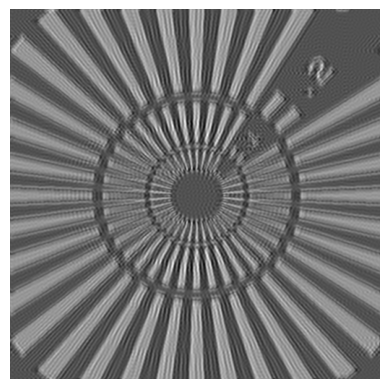

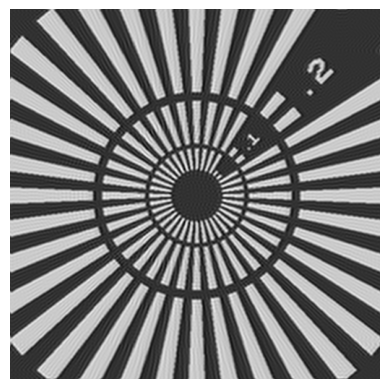

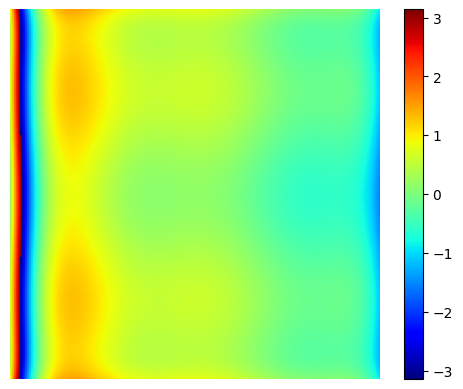

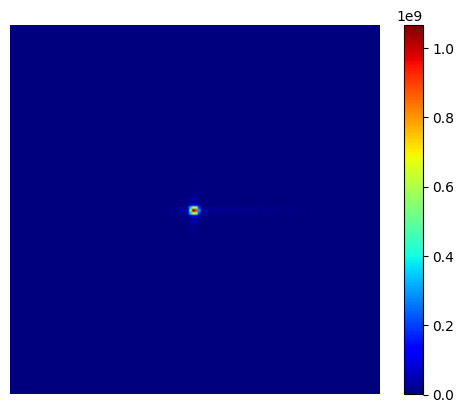

0.7533512571093257


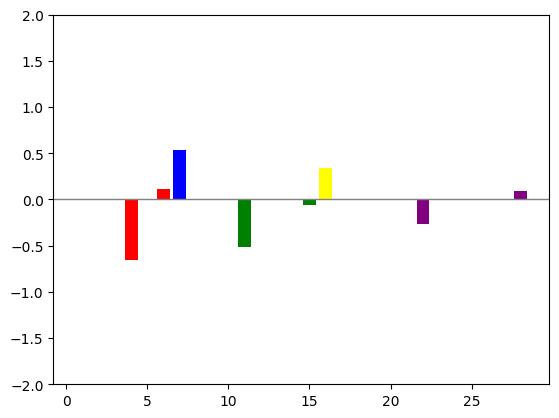

In [196]:
intensity, phage = imaging(coef)

plt.imshow(intensity, cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(phage, cmap='gray')
plt.axis('off')
plt.show()


pupil = make_wavefront(coef)
angle_pupil = np.angle(pupil[imax//2-int(aperture//2):imax//2+int(aperture//2),imax//2-int(aperture//2):imax//2+int(aperture//2)])
plt.imshow(angle_pupil, cmap='jet', vmin=-np.pi, vmax=np.pi)
plt.axis('off')
plt.colorbar()
plt.show()


psf_img = psf(pupil)
plt.imshow(psf_img[imax//2-int(128//2) : imax//2+int(128//2),
                                jmax//2-int(128//2) : jmax//2+int(128//2)], cmap='jet')
plt.colorbar()
plt.axis('off')
plt.show()

print(rms_calculate(pupil))
rms_result.append(rms_calculate(pupil))
plt.bar(range(1, 1+len(coef)), coef, color=colors)
plt.ylim(-2.0,2.0)
plt.axhline(y=0, color='gray', linestyle='-', linewidth=1)
plt.show()

  2%|▏         | 1/50 [00:02<01:44,  2.13s/it]

start:[1.87991258260961, -0.7115587126537619, 1.865816485127111, 0.7289317550831451, 1.1033230652509678]


100%|██████████| 50/50 [01:46<00:00,  2.12s/it]

Global best position:  [0.009469946746588704, -0.02575856710554474, -0.037437664210347, -0.016509030936902758, 0.009567794497162859]
Global best fitness:  0.3538649


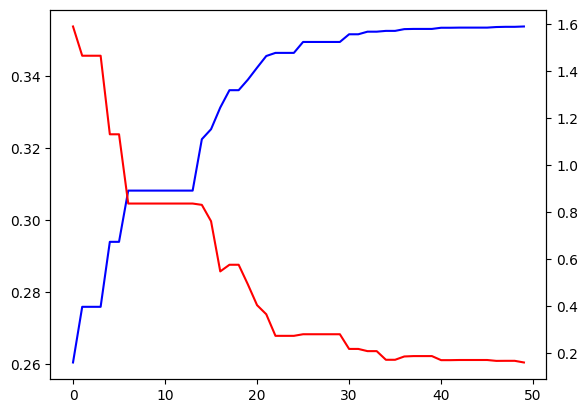

main took 106.14260 seconds


In [197]:
import random
import math
from tqdm import tqdm


class Particle:
    def __init__(self, num_variables, bounds):
        self.position = [random.uniform(
            bounds[i][0], bounds[i][1]) for i in range(num_variables)]
        self.velocity = [random.uniform(-0.5, 0.5) for _ in range(num_variables)]
        self.best_position = self.position[:]
        self.best_fitness = 0.0

        self.hash = hash(tuple(self.velocity) +
                         tuple(random.random() for _ in range(10)))

    def evaluate(self):
        global coef
        coef[3], coef[6], coef[10], coef[15], coef[21]= self.position #
        phase_img = phase_imaging(coef)
        phase_img_diff = cv2.Sobel(phase_img, cv2.CV_32F, 1, 0, ksize=3)
        phase_img_diff = np.abs(phase_img_diff)
        fitness = np.std(phase_img_diff)
        rms = rms_calculate(make_wavefront(coef))
        return fitness, rms


class PSO:
    def __init__(self, num_particles, num_variables, bounds, max_iterations):
        self.inertia_weight = 0.7
        self.cognitive_weight = 1.5
        self.social_weight = 1.5
        self.num_particles = num_particles
        self.num_variables = num_variables
        self.bounds = bounds
        self.max_iterations = max_iterations
        self.global_best_position = [2.0] * num_variables
        self.global_best_fitness = 0.0
        self.global_best_rms = None
        self.particles = [Particle(num_variables, bounds)
                          for _ in range(num_particles)]

        self.history = {particle.hash: [particle.position[:]]
                        for particle in self.particles}

        self.history[hash('global_best')] = [
            self.global_best_position[:]]

        self.iteration_used = 0
        self.blur_history = []
        self.rms_history = []

    def optimize(self):
        for i in tqdm(range(self.max_iterations)):
            for particle in self.particles:
                fitness, rms = particle.evaluate()
                if fitness > particle.best_fitness:
                    particle.best_fitness = fitness
                    particle.best_position = particle.position[:]
                if fitness > self.global_best_fitness:
                    self.global_best_fitness = fitness
                    self.global_best_rms = rms
                    self.global_best_position = particle.position[:]
                    self.history[hash('global_best')].append(
                        particle.position[:])
            if i == 0:
              print(f'start:{self.global_best_position}')
            self.blur_history.append(self.global_best_fitness)
            self.rms_history.append(self.global_best_rms)

            for particle in self.particles:
                for i in range(self.num_variables):
                    r1, r2 = random.random(), random.random()
                    particle.velocity[i] = (self.inertia_weight * particle.velocity[i] +
                                            self.cognitive_weight * r1 * (particle.best_position[i] - particle.position[i]) +
                                            self.social_weight * r2 * (self.global_best_position[i] - particle.position[i]))
                    particle.position[i] += particle.velocity[i]
                    if abs(particle.position[i]) > 2.0:
                       particle.position[i] = random.uniform(-2, 2)
                self.history[particle.hash].append(particle.position[:])

            self.iteration_used += 1


def draw(history, hash_key, iteration, color=PARTICLE_COLOR):
    if iteration >= len(history[hash_key]):
        return
    particle_position_at_iteration = history[hash_key][iteration]
    pygame.draw.circle(screen, color, (int(particle_position_at_iteration[0] * 10 + SCREEN_WIDTH / 2),
                                       int(particle_position_at_iteration[1] * 10 + SCREEN_HEIGHT / 2)), PARTICLE_RADIUS)

@timer
def main():
    num_particles = 20
    num_variables = 5
    bounds = [[-2, 2]] * num_variables
    max_iterations = 50


    optimizer = PSO(num_particles, num_variables, bounds, max_iterations)

    optimizer.optimize()

    print("Global best position: ", optimizer.global_best_position)
    print("Global best fitness: ", optimizer.global_best_fitness)

    coef[3], coef[6], coef[10], coef[15], coef[21] = optimizer.global_best_position
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(optimizer.blur_history, color='blue')
    ax2.plot(optimizer.rms_history, color='red')
    plt.show()


if __name__ == "__main__":
    main()

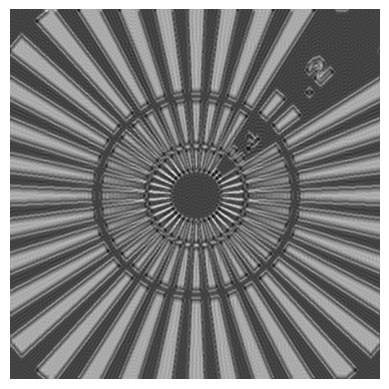

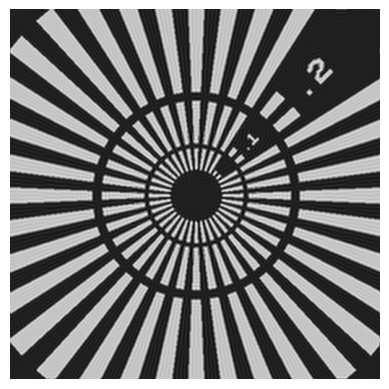

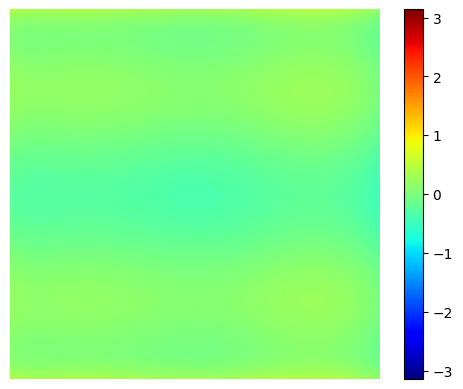

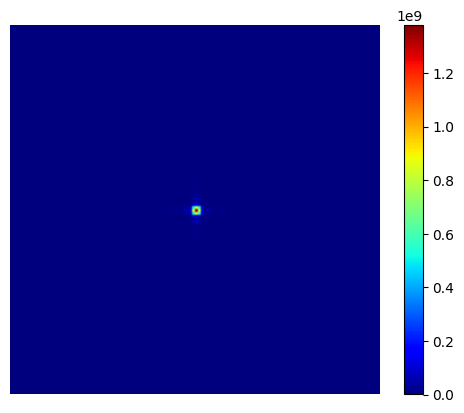

0.16104246366252822


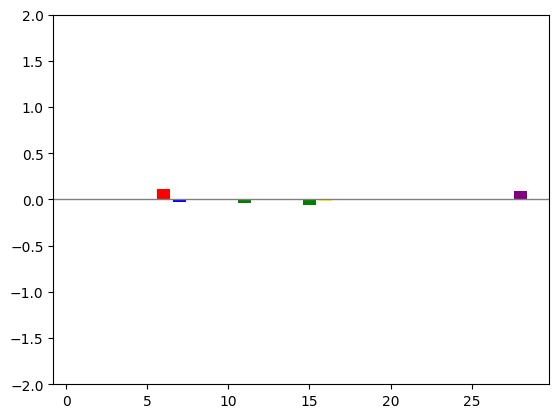

In [198]:
intensity, phage = imaging(coef)

plt.imshow(intensity, cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(phage, cmap='gray')
plt.axis('off')
plt.show()


pupil = make_wavefront(coef)
angle_pupil = np.angle(pupil[imax//2-int(aperture//2):imax//2+int(aperture//2),imax//2-int(aperture//2):imax//2+int(aperture//2)])
plt.imshow(angle_pupil, cmap='jet', vmin=-np.pi, vmax=np.pi)
plt.axis('off')
plt.colorbar()
plt.show()


psf_img = psf(pupil)
plt.imshow(psf_img[imax//2-int(128//2) : imax//2+int(128//2),
                                jmax//2-int(128//2) : jmax//2+int(128//2)], cmap='jet')
plt.colorbar()
plt.axis('off')
plt.show()

print(rms_calculate(pupil))
plt.bar(range(1, 1+len(coef)), coef, color=colors)
plt.ylim(-2.0,2.0)
plt.axhline(y=0, color='gray', linestyle='-', linewidth=1)
plt.show()

In [19]:
rms_result = []
rms_start = []

In [160]:
print(rms_result)
print(rms_start)

[np.float64(0.09893012210132919), np.float64(0.2510311163876838)]
[np.float64(1.8011718061253856), np.float64(1.8539004209685286)]


In [159]:
rms_result.pop()
rms_start.pop()

np.float64(1.6919413428415186)

In [29]:
@timer
def time_test():
  coef = [0.0]*28
  coef[3], coef[5], coef[6], coef[9], coef[10], coef[14], coef[15], coef[20], coef[21], coef[27] = [1.0]*10
  phase_img = phase_imaging(coef)
  fitness = laplacian_score(phase_img)

time_test()

time_test took 0.07550 seconds


## 縦横別々2

In [27]:
rms_result = []
rms_start = []

Legendre dimension, mode :  6, 28
[0.0, 0.0, 0.0, 1.538246912744348, 0.0, -0.2896607419371251, 0.8245696966843821, 0.0, 0.0, -0.1949282541185826, -0.15763967482761165, 0.0, 0.0, 0.0, 0.3121677035994903, -0.009196834150229094, 0.0, 0.0, 0.0, 0.0, 1.1114418479904575, -0.9277999406883644, 0.0, 0.0, 0.0, 0.0, 0.0, 1.9692397237813921]


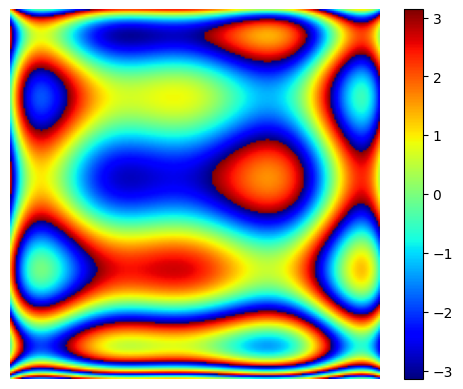

In [35]:
N = 10

coef_w = 4     # Legendre多項式の係数幅
limit = coef_w/2
maxD    = 6                    # Legendre多項式の最大次数
mode = (maxD+1)*(maxD+2)//2     # Legendre modeの数
print("Legendre dimension, mode : ", str(maxD) + ", " + str(mode))

target = [random.uniform(0.0, coef_w)-coef_w/2 for i in range(N)]   # Legendre多項式の係数
coef = [0.0] * mode
coef[3], coef[5], coef[6], coef[9], coef[10], coef[14], coef[15], coef[20], coef[21], coef[27] = target

print(coef)
pupil = make_wavefront(coef)
angle_pupil = np.angle(pupil[imax//2-int(aperture//2):imax//2+int(aperture//2),imax//2-int(aperture//2):imax//2+int(aperture//2)])
plt.imshow(angle_pupil, cmap='jet', vmin=-np.pi, vmax=np.pi)
plt.axis('off')
plt.colorbar()
plt.show()

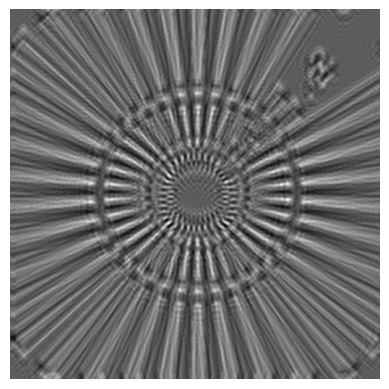

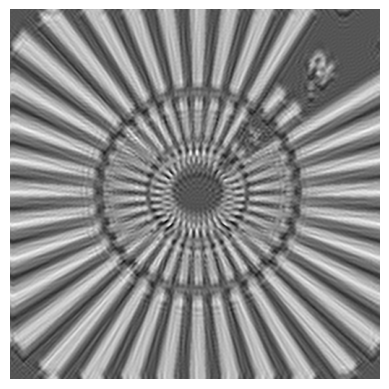

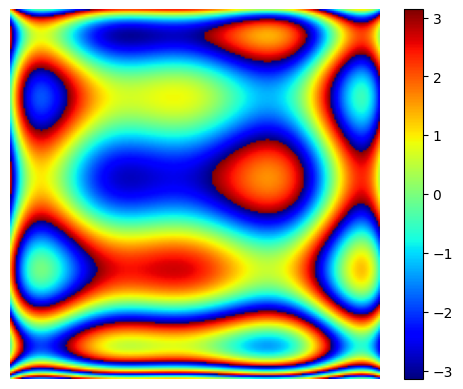

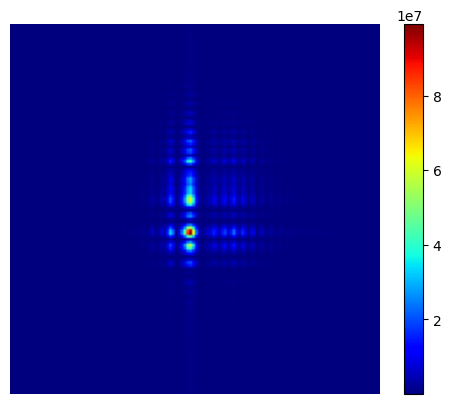

1.8010190497471479


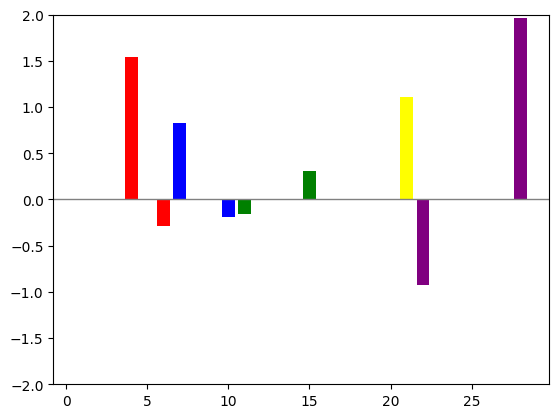

In [36]:
intensity, phage = imaging(coef)

plt.imshow(intensity, cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(phage, cmap='gray')
plt.axis('off')
plt.show()


pupil = make_wavefront(coef)
angle_pupil = np.angle(pupil[imax//2-int(aperture//2):imax//2+int(aperture//2),imax//2-int(aperture//2):imax//2+int(aperture//2)])
plt.imshow(angle_pupil, cmap='jet', vmin=-np.pi, vmax=np.pi)
plt.axis('off')
plt.colorbar()
plt.show()


psf_img = psf(pupil)
plt.imshow(psf_img[imax//2-int(128//2) : imax//2+int(128//2),
                                jmax//2-int(128//2) : jmax//2+int(128//2)], cmap='jet')
plt.colorbar()
plt.axis('off')
plt.show()

print(rms_calculate(pupil))
rms_start.append(rms_calculate(pupil))
plt.bar(range(1, 1+len(coef)), coef, color=colors)
plt.ylim(-2.0,2.0)
plt.axhline(y=0, color='gray', linestyle='-', linewidth=1)
plt.show()

  2%|▏         | 1/50 [00:00<00:24,  1.97it/s]

start:[-1.8901257580245057, -0.22147224700255563, -0.9202992596416948, 1.0804812624648896, 0.23086925251241963]


100%|██████████| 50/50 [00:24<00:00,  2.03it/s]

Global best position:  [0.0438508310848586, 0.015444164721455406, 0.12345775045345019, -0.012156245803111667, 0.09624497952054498]
Global best fitness:  0.34206638


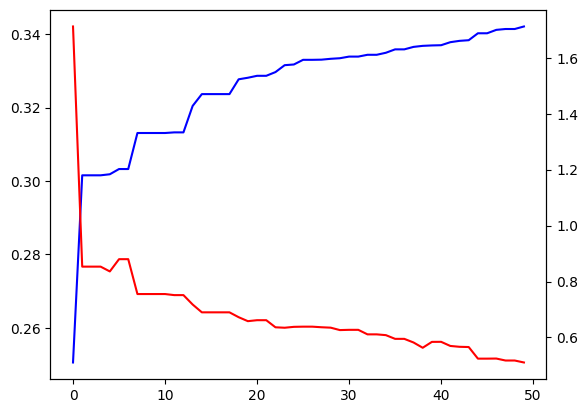

main took 24.76218 seconds


In [42]:
import random
import math
from tqdm import tqdm


class Particle:
    def __init__(self, num_variables, bounds):
        self.position = [random.uniform(
            bounds[i][0], bounds[i][1]) for i in range(num_variables)]
        self.velocity = [random.uniform(-0.5, 0.5) for _ in range(num_variables)]
        self.best_position = self.position[:]
        self.best_fitness = 0.0

        self.hash = hash(tuple(self.velocity) +
                         tuple(random.random() for _ in range(10)))

    def evaluate(self):
        global coef
        coef[3], coef[6], coef[10], coef[15], coef[21]= self.position #
        phase_img = phase_imaging(coef)
        phase_img_diff = cv2.Sobel(phase_img, cv2.CV_32F, 1, 0, ksize=3)
        phase_img_diff = np.abs(phase_img_diff)
        fitness = np.std(phase_img_diff)
        # fitness = laplacian_score(phase_img)
        rms = rms_calculate(make_wavefront(coef))
        return fitness, rms


class PSO:
    def __init__(self, num_particles, num_variables, bounds, max_iterations):
        self.inertia_weight = 0.7
        self.cognitive_weight = 1.5
        self.social_weight = 1.5
        self.num_particles = num_particles
        self.num_variables = num_variables
        self.bounds = bounds
        self.max_iterations = max_iterations
        self.global_best_position = [2.0] * num_variables
        self.global_best_fitness = 0.0
        self.global_best_rms = None
        self.particles = [Particle(num_variables, bounds)
                          for _ in range(num_particles)]

        self.history = {particle.hash: [particle.position[:]]
                        for particle in self.particles}

        self.history[hash('global_best')] = [
            self.global_best_position[:]]

        self.iteration_used = 0
        self.blur_history = []
        self.rms_history = []

    def optimize(self):
        for i in tqdm(range(self.max_iterations)):
            for particle in self.particles:
                fitness, rms = particle.evaluate()
                if fitness > particle.best_fitness:
                    particle.best_fitness = fitness
                    particle.best_position = particle.position[:]
                if fitness > self.global_best_fitness:
                    self.global_best_fitness = fitness
                    self.global_best_rms = rms
                    self.global_best_position = particle.position[:]
                    self.history[hash('global_best')].append(
                        particle.position[:])
            if i == 0:
              print(f'start:{self.global_best_position}')
            self.blur_history.append(self.global_best_fitness)
            self.rms_history.append(self.global_best_rms)

            for particle in self.particles:
                for i in range(self.num_variables):
                    r1, r2 = random.random(), random.random()
                    particle.velocity[i] = (self.inertia_weight * particle.velocity[i] +
                                            self.cognitive_weight * r1 * (particle.best_position[i] - particle.position[i]) +
                                            self.social_weight * r2 * (self.global_best_position[i] - particle.position[i]))
                    particle.position[i] += particle.velocity[i]
                    if abs(particle.position[i]) > 2.0:
                       particle.position[i] = random.uniform(-2, 2)
                self.history[particle.hash].append(particle.position[:])

            self.iteration_used += 1




@timer
def main():
    num_particles = 5
    num_variables = 5
    bounds = [[-2, 2]] * num_variables
    max_iterations = 50


    optimizer = PSO(num_particles, num_variables, bounds, max_iterations)

    optimizer.optimize()

    print("Global best position: ", optimizer.global_best_position)
    print("Global best fitness: ", optimizer.global_best_fitness)

    coef[3], coef[6], coef[10], coef[15], coef[21] = optimizer.global_best_position
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(optimizer.blur_history, color='blue')
    ax2.plot(optimizer.rms_history, color='red')
    plt.show()


if __name__ == "__main__":
    main()

In [43]:
print(coef)

[0.0, 0.0, 0.0, 0.0438508310848586, 0.0, 0.07719205101257227, 0.015444164721455406, 0.0, 0.0, 0.46892185839754313, 0.12345775045345019, 0.0, 0.0, 0.0, -0.03681522829943318, -0.012156245803111667, 0.0, 0.0, 0.0, 0.0, -0.06743656761625359, 0.09624497952054498, 0.0, 0.0, 0.0, 0.0, 0.0, 0.11933231718115248]


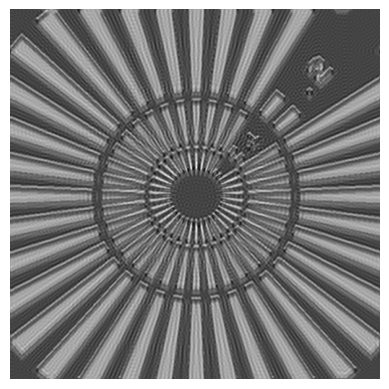

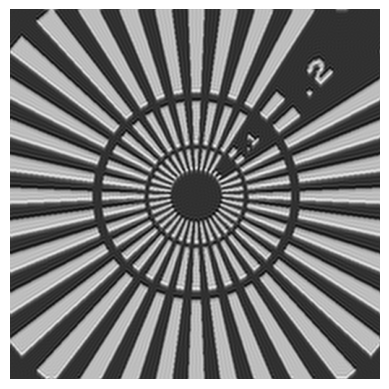

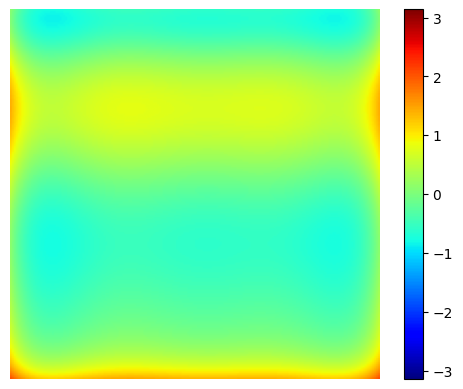

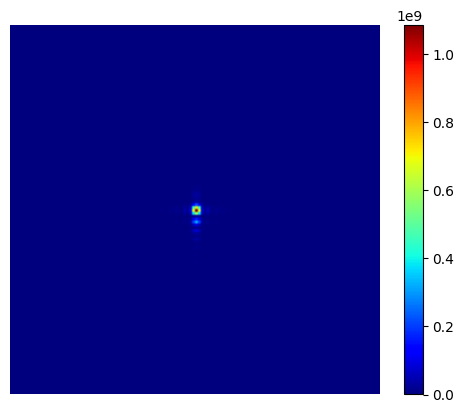

0.5106027609041929


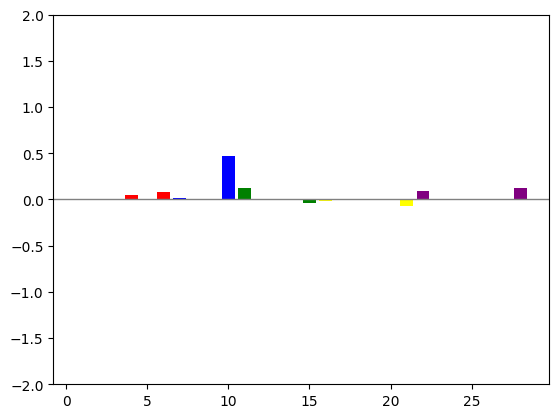

In [44]:
intensity, phage = imaging(coef)

plt.imshow(intensity, cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(phage, cmap='gray')
plt.axis('off')
plt.show()


pupil = make_wavefront(coef)
angle_pupil = np.angle(pupil[imax//2-int(aperture//2):imax//2+int(aperture//2),imax//2-int(aperture//2):imax//2+int(aperture//2)])
plt.imshow(angle_pupil, cmap='jet', vmin=-np.pi, vmax=np.pi)
plt.axis('off')
plt.colorbar()
plt.show()


psf_img = psf(pupil)
plt.imshow(psf_img[imax//2-int(128//2) : imax//2+int(128//2),
                                jmax//2-int(128//2) : jmax//2+int(128//2)], cmap='jet')
plt.colorbar()
plt.axis('off')
plt.show()

print(rms_calculate(pupil))
plt.bar(range(1, 1+len(coef)), coef, color=colors)
plt.ylim(-2.0,2.0)
plt.axhline(y=0, color='gray', linestyle='-', linewidth=1)
plt.show()

  2%|▏         | 1/50 [00:00<00:24,  2.01it/s]

start:[-0.08158353525224893, 1.0235661237766167, -0.3841217997994888, -1.4634723964183394, -1.7177354338313573]


100%|██████████| 50/50 [00:24<00:00,  2.03it/s]

Global best position:  [0.07719205101257227, 0.46892185839754313, -0.03681522829943318, -0.06743656761625359, 0.11933231718115248]
Global best fitness:  0.038244005


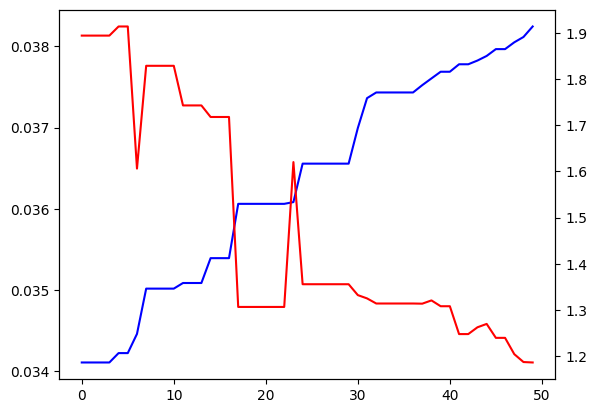

main took 24.71335 seconds


In [40]:
import random
import math
from tqdm import tqdm

import pygame
from pygame.locals import *

pygame.init()
SCREEN_WIDTH = 800
SCREEN_HEIGHT = 600
BACKGROUND_COLOR = (255, 255, 255)
PARTICLE_COLOR = (0, 0, 0)
PARTICLE_RADIUS = 5

screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))
pygame.display.set_caption("Particle Swarm Optimization")


class Particle:
    def __init__(self, num_variables, bounds):
        self.position = [random.uniform(
            bounds[i][0], bounds[i][1]) for i in range(num_variables)]
        self.velocity = [random.uniform(-0.5, 0.5) for _ in range(num_variables)]
        self.best_position = self.position[:]
        self.best_fitness = 0.0

        self.hash = hash(tuple(self.velocity) +
                         tuple(random.random() for _ in range(10)))

    def evaluate(self):
        global coef
        coef[5], coef[9], coef[14], coef[20], coef[27] = self.position #coef[21], coef[27]
        phase_img = phase_imaging(coef)
        fitness = laplacian_score(phase_img)
        rms = rms_calculate(make_wavefront(coef))
        return fitness, rms


class PSO:
    def __init__(self, num_particles, num_variables, bounds, max_iterations):
        self.inertia_weight = 0.7
        self.cognitive_weight = 1.5
        self.social_weight = 1.5
        self.num_particles = num_particles
        self.num_variables = num_variables
        self.bounds = bounds
        self.max_iterations = max_iterations
        self.global_best_position = [2.0] * num_variables
        self.global_best_fitness = 0.0
        self.global_best_rms = None
        self.particles = [Particle(num_variables, bounds)
                          for _ in range(num_particles)]

        self.history = {particle.hash: [particle.position[:]]
                        for particle in self.particles}

        self.history[hash('global_best')] = [
            self.global_best_position[:]]

        self.iteration_used = 0
        self.blur_history = []
        self.rms_history = []

    def optimize(self):
        for i in tqdm(range(self.max_iterations)):
            for particle in self.particles:
                fitness, rms = particle.evaluate()
                if fitness > particle.best_fitness:
                    particle.best_fitness = fitness
                    particle.best_position = particle.position[:]
                if fitness > self.global_best_fitness:
                    self.global_best_fitness = fitness
                    self.global_best_rms = rms
                    self.global_best_position = particle.position[:]
                    self.history[hash('global_best')].append(
                        particle.position[:])
            if i == 0:
              print(f'start:{self.global_best_position}')
            self.blur_history.append(self.global_best_fitness)
            self.rms_history.append(self.global_best_rms)

            for particle in self.particles:
                for i in range(self.num_variables):
                    r1, r2 = random.random(), random.random()
                    particle.velocity[i] = (self.inertia_weight * particle.velocity[i] +
                                            self.cognitive_weight * r1 * (particle.best_position[i] - particle.position[i]) +
                                            self.social_weight * r2 * (self.global_best_position[i] - particle.position[i]))
                    particle.position[i] += particle.velocity[i]
                    if abs(particle.position[i]) > 2.0:
                       particle.position[i] = random.uniform(-2, 2)
                self.history[particle.hash].append(particle.position[:])

            self.iteration_used += 1




@timer
def main():
    num_particles = 5
    num_variables = 5
    bounds = [[-2, 2]] * num_variables
    max_iterations = 50


    optimizer = PSO(num_particles, num_variables, bounds, max_iterations)

    optimizer.optimize()

    print("Global best position: ", optimizer.global_best_position)
    print("Global best fitness: ", optimizer.global_best_fitness)

    coef[5], coef[9], coef[14], coef[20], coef[27] = optimizer.global_best_position

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(optimizer.blur_history, color='blue')
    ax2.plot(optimizer.rms_history, color='red')
    plt.show()


if __name__ == "__main__":
    main()

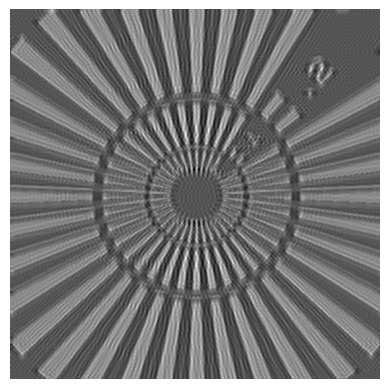

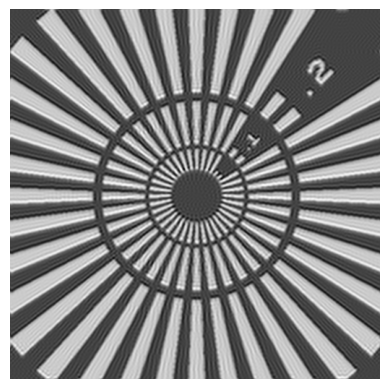

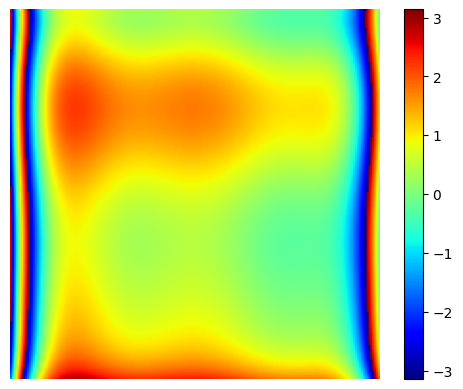

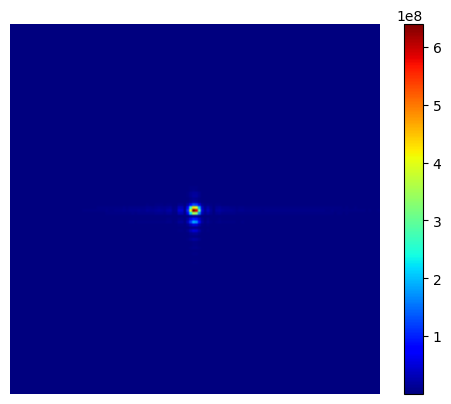

1.1859122537679925


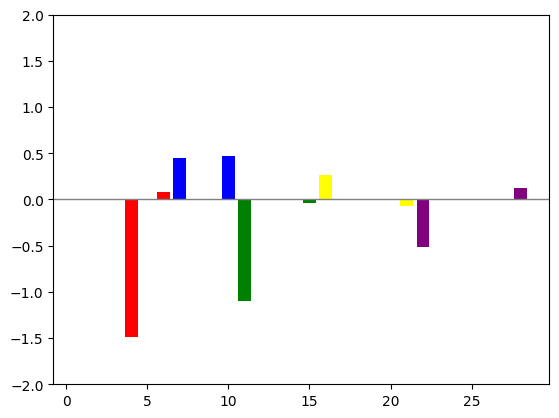

In [41]:
intensity, phage = imaging(coef)

plt.imshow(intensity, cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(phage, cmap='gray')
plt.axis('off')
plt.show()


pupil = make_wavefront(coef)
angle_pupil = np.angle(pupil[imax//2-int(aperture//2):imax//2+int(aperture//2),imax//2-int(aperture//2):imax//2+int(aperture//2)])
plt.imshow(angle_pupil, cmap='jet', vmin=-np.pi, vmax=np.pi)
plt.axis('off')
plt.colorbar()
plt.show()


psf_img = psf(pupil)
plt.imshow(psf_img[imax//2-int(128//2) : imax//2+int(128//2),
                                jmax//2-int(128//2) : jmax//2+int(128//2)], cmap='jet')
plt.colorbar()
plt.axis('off')
plt.show()

print(rms_calculate(pupil))
rms_result.append(rms_calculate(pupil))
plt.bar(range(1, 1+len(coef)), coef, color=colors)
plt.ylim(-2.0,2.0)
plt.axhline(y=0, color='gray', linestyle='-', linewidth=1)
plt.show()

  2%|▏         | 1/50 [00:02<01:41,  2.06s/it]

start:[-0.4468258102763576, 0.6756224641563313, -0.21370648023809835, -0.8499295312568096, -0.0808899657163451]


100%|██████████| 50/50 [01:42<00:00,  2.06s/it]

Global best position:  [-0.0631104503056675, 0.0019962751868868945, 0.02306674955572078, 0.010274282221658272, 0.001047981612731095]
Global best fitness:  0.34180057


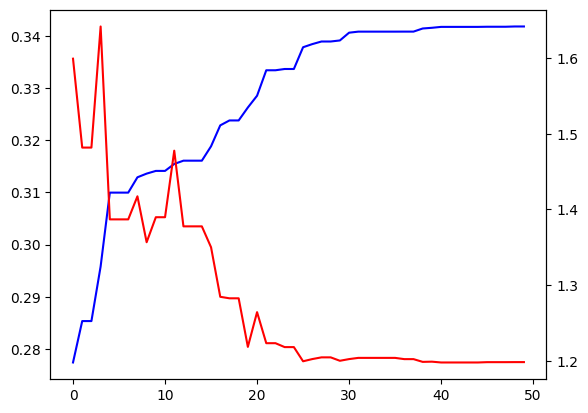

main took 102.93702 seconds


In [60]:
import random
import math
from tqdm import tqdm


class Particle:
    def __init__(self, num_variables, bounds):
        self.position = [random.uniform(
            bounds[i][0], bounds[i][1]) for i in range(num_variables)]
        self.velocity = [random.uniform(-0.5, 0.5) for _ in range(num_variables)]
        self.best_position = self.position[:]
        self.best_fitness = 0.0

        self.hash = hash(tuple(self.velocity) +
                         tuple(random.random() for _ in range(10)))

    def evaluate(self):
        global coef
        coef[3], coef[6], coef[10], coef[15], coef[21]= self.position #
        phase_img = phase_imaging(coef)
        phase_img_diff = cv2.Sobel(phase_img, cv2.CV_32F, 1, 0, ksize=3)
        phase_img_diff = np.abs(phase_img_diff)
        fitness = np.std(phase_img_diff)
        rms = rms_calculate(make_wavefront(coef))
        return fitness, rms


class PSO:
    def __init__(self, num_particles, num_variables, bounds, max_iterations):
        self.inertia_weight = 0.7
        self.cognitive_weight = 1.5
        self.social_weight = 1.5
        self.num_particles = num_particles
        self.num_variables = num_variables
        self.bounds = bounds
        self.max_iterations = max_iterations
        self.global_best_position = [2.0] * num_variables
        self.global_best_fitness = 0.0
        self.global_best_rms = None
        self.particles = [Particle(num_variables, bounds)
                          for _ in range(num_particles)]

        self.history = {particle.hash: [particle.position[:]]
                        for particle in self.particles}

        self.history[hash('global_best')] = [
            self.global_best_position[:]]

        self.iteration_used = 0
        self.blur_history = []
        self.rms_history = []

    def optimize(self):
        for i in tqdm(range(self.max_iterations)):
            for particle in self.particles:
                fitness, rms = particle.evaluate()
                if fitness > particle.best_fitness:
                    particle.best_fitness = fitness
                    particle.best_position = particle.position[:]
                if fitness > self.global_best_fitness:
                    self.global_best_fitness = fitness
                    self.global_best_rms = rms
                    self.global_best_position = particle.position[:]
                    self.history[hash('global_best')].append(
                        particle.position[:])
            if i == 0:
              print(f'start:{self.global_best_position}')
            self.blur_history.append(self.global_best_fitness)
            self.rms_history.append(self.global_best_rms)

            for particle in self.particles:
                for i in range(self.num_variables):
                    r1, r2 = random.random(), random.random()
                    particle.velocity[i] = (self.inertia_weight * particle.velocity[i] +
                                            self.cognitive_weight * r1 * (particle.best_position[i] - particle.position[i]) +
                                            self.social_weight * r2 * (self.global_best_position[i] - particle.position[i]))
                    particle.position[i] += particle.velocity[i]
                    if abs(particle.position[i]) > 2.0:
                       particle.position[i] = random.uniform(-2, 2)
                self.history[particle.hash].append(particle.position[:])

            self.iteration_used += 1


def draw(history, hash_key, iteration, color=PARTICLE_COLOR):
    if iteration >= len(history[hash_key]):
        return
    particle_position_at_iteration = history[hash_key][iteration]
    pygame.draw.circle(screen, color, (int(particle_position_at_iteration[0] * 10 + SCREEN_WIDTH / 2),
                                       int(particle_position_at_iteration[1] * 10 + SCREEN_HEIGHT / 2)), PARTICLE_RADIUS)

@timer
def main():
    num_particles = 20
    num_variables = 5
    bounds = [[-2, 2]] * num_variables
    max_iterations = 50


    optimizer = PSO(num_particles, num_variables, bounds, max_iterations)

    optimizer.optimize()

    print("Global best position: ", optimizer.global_best_position)
    print("Global best fitness: ", optimizer.global_best_fitness)

    coef[3], coef[6], coef[10], coef[15], coef[21] = optimizer.global_best_position
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(optimizer.blur_history, color='blue')
    ax2.plot(optimizer.rms_history, color='red')
    plt.show()


if __name__ == "__main__":
    main()

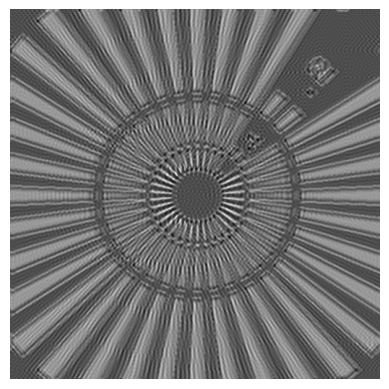

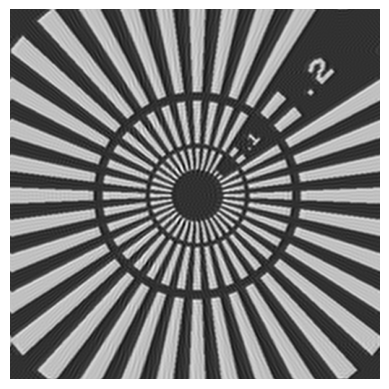

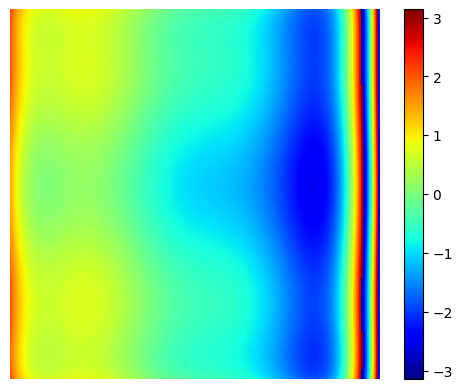

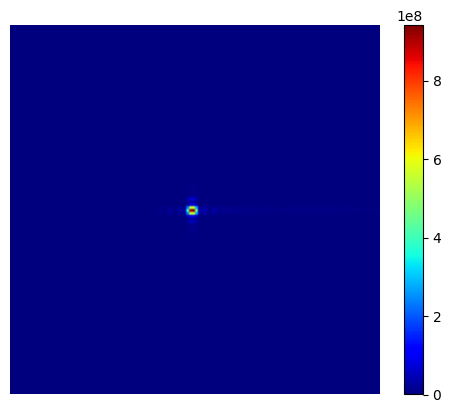

1.1321875957035012


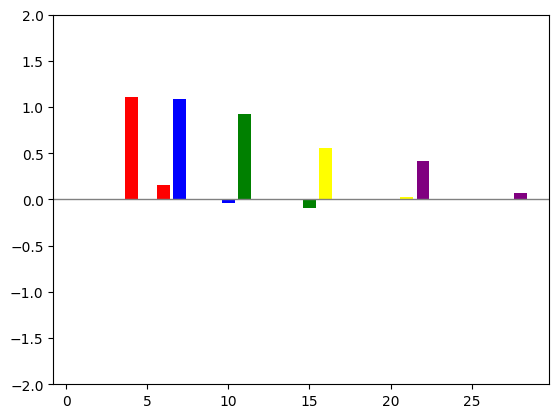

In [41]:
intensity, phage = imaging(coef)

plt.imshow(intensity, cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(phage, cmap='gray')
plt.axis('off')
plt.show()


pupil = make_wavefront(coef)
angle_pupil = np.angle(pupil[imax//2-int(aperture//2):imax//2+int(aperture//2),imax//2-int(aperture//2):imax//2+int(aperture//2)])
plt.imshow(angle_pupil, cmap='jet', vmin=-np.pi, vmax=np.pi)
plt.axis('off')
plt.colorbar()
plt.show()


psf_img = psf(pupil)
plt.imshow(psf_img[imax//2-int(128//2) : imax//2+int(128//2),
                                jmax//2-int(128//2) : jmax//2+int(128//2)], cmap='jet')
plt.colorbar()
plt.axis('off')
plt.show()

print(rms_calculate(pupil))
plt.bar(range(1, 1+len(coef)), coef, color=colors)
plt.ylim(-2.0,2.0)
plt.axhline(y=0, color='gray', linestyle='-', linewidth=1)
plt.show()